# Pick apart the components of the response

In [3]:
%load_ext autoreload
%autoreload 2
import sys

sys.path.append('../../')

from pathlib import Path
from pathlib import PosixPath


import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold

from sklearn.metrics import r2_score
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import KFold, cross_val_score, StratifiedKFold
from sklearn.naive_bayes import GaussianNB

from tools.params import Params
import tools.dimensionality as dim
import tools.decoding as decode
import tools.viz.utilityTools as vizutils

from dPCA import dPCA


In [8]:
def drop_by_perturb_score(perturb_score, thresh_val=-2.0, stat="sem", verbose=True):
    a = np.asarray(perturb_score, float)
    mean = a.mean(axis=1)
    spread = a.std(axis=1) / (np.sqrt(a.shape[1]) if stat == "sem" else 1.0)

    with np.errstate(invalid="ignore"):
        by_spread = (mean + spread) < 0        # (1) unperturbed
        by_value = mean > thresh_val           # (2) stopped
    keep = by_spread & by_value

    if verbose:
        print(f"  drop_by_perturb_score ({stat}, thresh={thresh_val}): "
              f"dropped by {stat}: {(~by_spread).sum()}  |  "
              f"dropped by value: {(~by_value).sum()}  |  "
              f"kept: {keep.sum()}/{len(keep)} ({100 * keep.sum() / len(keep):.1f}%)")
    return keep

## Load cache

In [3]:
# Load the per-session decoding results saved by
# across-sessions/bhv-decode-solenoid/decode_solenoid_direction.py


DATA_DIR = Path('/mnt/datascience/workspaces/mesparza-40inbrain-2dneuroelectronics-2ecom/equake-interim-results/cache')
npz_files = sorted(DATA_DIR.glob('*.npz'))
npz_files = [
    # PosixPath('/mnt/datascience/workspaces/mesparza-40inbrain-2dneuroelectronics-2ecom/equake-interim-results/cache/M061_2025_03_04_10_00.npz'),
    # PosixPath('/mnt/datascience/workspaces/mesparza-40inbrain-2dneuroelectronics-2ecom/equake-interim-results/cache/M061_2025_03_05_14_00.npz'),
    PosixPath('/mnt/datascience/workspaces/mesparza-40inbrain-2dneuroelectronics-2ecom/equake-interim-results/cache/M061_2025_03_06_14_00.npz'),
    # PosixPath('/mnt/datascience/workspaces/mesparza-40inbrain-2dneuroelectronics-2ecom/equake-interim-results/cache/M062_2025_03_20_14_00.npz'),
    # PosixPath('/mnt/datascience/workspaces/mesparza-40inbrain-2dneuroelectronics-2ecom/equake-interim-results/cache/M062_2025_03_21_14_00.npz'),
    # PosixPath('/mnt/datascience/workspaces/mesparza-40inbrain-2dneuroelectronics-2ecom/equake-interim-results/cache/M063_2025_03_13_14_00.npz'),
    # PosixPath('/mnt/datascience/workspaces/mesparza-40inbrain-2dneuroelectronics-2ecom/equake-interim-results/cache/M078_2025_08_06_15_00.npz'),
    # PosixPath('/mnt/datascience/workspaces/mesparza-40inbrain-2dneuroelectronics-2ecom/equake-interim-results/cache/M086_2025_12_10_15_00.npz'),
    # PosixPath('/mnt/datascience/workspaces/mesparza-40inbrain-2dneuroelectronics-2ecom/equake-interim-results/cache/M103_2026_02_18_15_30.npz'),
    # PosixPath('/mnt/datascience/workspaces/mesparza-40inbrain-2dneuroelectronics-2ecom/equake-interim-results/cache/M103_2026_02_19_15_30.npz'),
    # PosixPath('/mnt/datascience/workspaces/mesparza-40inbrain-2dneuroelectronics-2ecom/equake-interim-results/cache/M106_2026_02_25_15_00.npz')
]

sessions_all = []
fixed_scores_all = []   # per session: (n_folds,) LDA accuracy, POST window
moving_scores_all = []  # per session: (n_windows,) GaussianNB accuracy, mean across folds
moving_time_s = None
chance = None

for f in npz_files:
    d = np.load(f, allow_pickle=True)
    sessions_all.append(str(d['session']))


print(f"{len(sessions_all)} sessions loaded: {sessions_all}")

1 sessions loaded: ['M061_2025_03_06_14_00']


In [4]:
d['session']

array('M061_2025_03_06_14_00', dtype='<U21')

In [66]:
FS = 100
BASE = (-1.6, -0.1)     # baseline window (s, rel. onset)
POST = (0.0, 1.0)       # response window
RESPONSE = (-1, 1.5)
N_SHUFFLE = 200
onset = 200
base_sl = slice(onset + int(BASE[0] * FS), onset + int(BASE[1] * FS))
post_sl = slice(onset + int(POST[0] * FS), onset + int(POST[1] * FS))
resp_sl = slice(onset + int(RESPONSE[0] * FS), onset + int(RESPONSE[1] * FS))



In [9]:
X_ = d['ep_X']
bl_std = X_[:, base_sl, :].std(1)
# Xz = X_ / np.expand_dims(bl_std, 1)
Xz = X_

In [10]:
# Apply to the session currently in `d`. Use the EPOCHED side: ep_* and cont_* hold DIFFERENT
# trial selections (different upstream filters) and different lengths -- never index one with a
# mask built from the other.

keep = drop_by_perturb_score(d["ep_perturb_score"], stat='sem')
X_kept = Xz[keep]
print(f"\nX  {Xz.shape}  ->  X_kept {X_kept.shape}")


  drop_by_perturb_score (sem, thresh=-2.0): dropped by sem: 36  |  dropped by value: 0  |  kept: 208/244 (85.2%)

X  (244, 401, 57)  ->  X_kept (208, 401, 57)


## Sliding window analysis

In [8]:
for k in d.keys():
    print(k)

ep_X
ep_onset
ep_code
ep_angle
ep_level
ep_trial_index
ep_trial_name
ep_perturb_score
ep_perturb_score_mean
ep_perturb_score_log_sum
labels
cont_Y
cont_speed
cont_phase
cont_seg_of
cont_onsets
cont_angle
cont_trial_index
cont_perturb_score
f0
fs
cont_code
cont_level
session


In [61]:

scores_cont_level, time = decode.moving_window_decoding(
    X_kept[:, resp_sl, :],
    d['ep_level'][keep],
    window_length_bin=30,
    step_bin=2,
    cv=StratifiedKFold(5, shuffle=True)
)

scores_cont_angle, time = decode.moving_window_decoding(
    X_kept[:, resp_sl, :],
    d['ep_angle'][keep],
    window_length_bin=30,
    step_bin=2,
    cv=StratifiedKFold(5, shuffle=True)
)

  0%|          | 0/136 [00:00<?, ?it/s]

100%|██████████| 136/136 [00:02<00:00, 48.19it/s]


Text(0, 0.5, 'Accuracy')

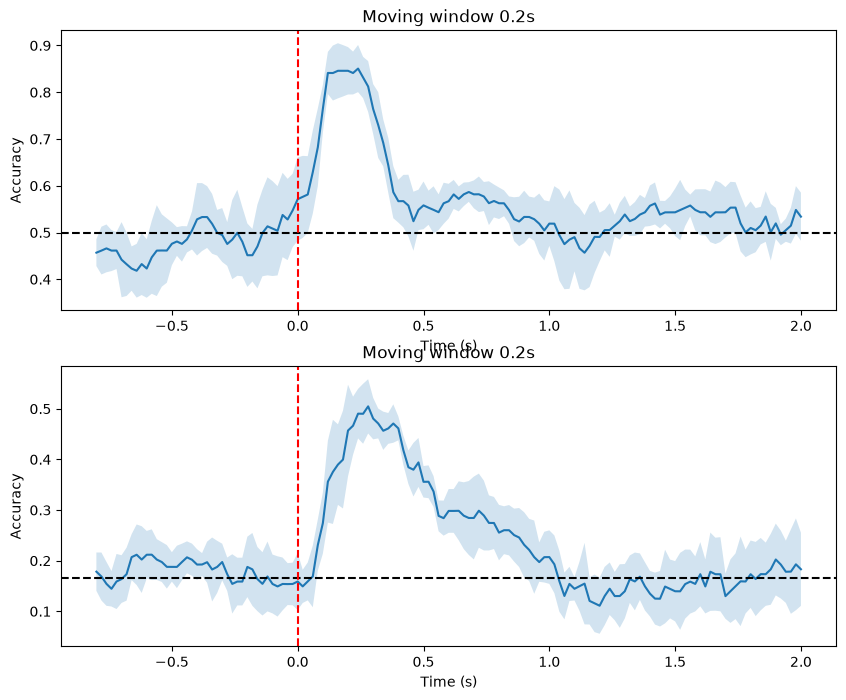

In [47]:
fig, axs = plt.subplots(2, 1, figsize=(10, 8))
ax = axs[0]
vizutils.shaded_errorbar(ax, time-1, scores_cont_level)
ax.axhline(1/2, label='chance', c='k', ls='--')
ax.axvline(0, label='perturb', c='r', ls='--')
ax.set_title('Moving window 0.2s')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Accuracy')

ax = axs[1]
vizutils.shaded_errorbar(ax, time-1, scores_cont_angle)
ax.axhline(1/6, label='chance', c='k', ls='--')
ax.axvline(0, label='perturb', c='r', ls='--')
ax.set_title('Moving window 0.2s')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Accuracy')


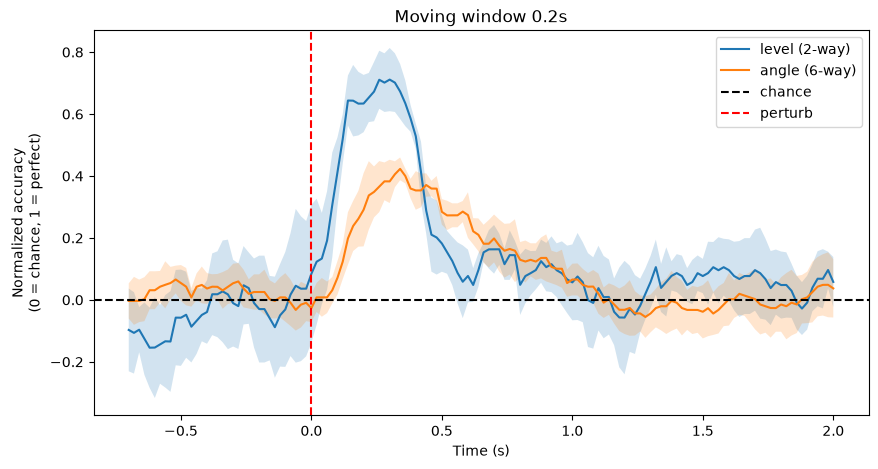

In [58]:
fig, ax = plt.subplots(figsize=(10, 5))

def norm(scores, chance):
    return (scores - chance) / (1 - chance)

vizutils.shaded_errorbar(ax, time - 1, norm(scores_cont_level, 1/2),
                         label='level (2-way)')
vizutils.shaded_errorbar(ax, time - 1, norm(scores_cont_angle, 1/6),
                          label='angle (6-way)')

ax.axhline(0, c='k', ls='--', label='chance')
ax.axvline(0, c='r', ls='--', label='perturb')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Normalized accuracy\n(0 = chance, 1 = perfect)')
ax.set_title('Moving window 0.2s')
ax.legend()

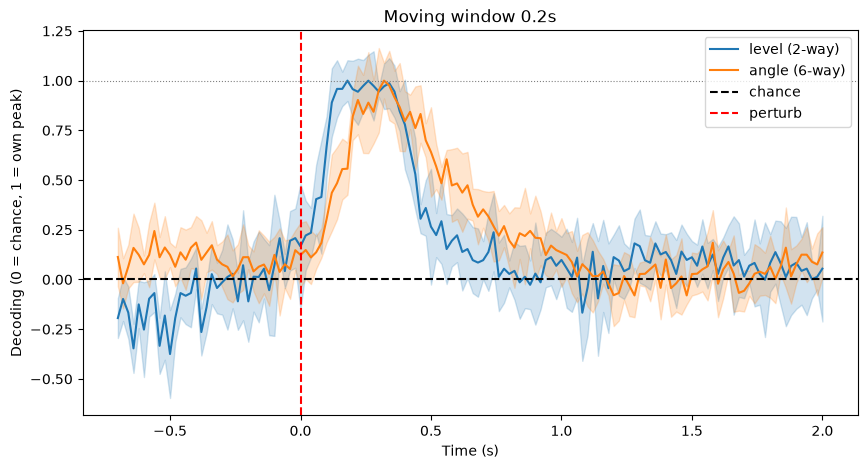

In [62]:
fig, ax = plt.subplots(figsize=(10, 5))

def norm_to_peak(scores, chance):
    """chance -> 0, peak of the fold-mean curve -> 1. Same scaling applied
    to every fold so the error band scales with the line."""
    peak = scores.mean(axis=1).max()
    return (scores - chance) / (peak - chance)

vizutils.shaded_errorbar(ax, time - 1, norm_to_peak(scores_cont_level, 1/2),
                         color='tab:blue', label='level (2-way)')
vizutils.shaded_errorbar(ax, time - 1, norm_to_peak(scores_cont_angle, 1/6),
                         color='tab:orange', label='angle (6-way)')

ax.axhline(0, c='k', ls='--', label='chance')
ax.axhline(1, c='grey', ls=':', lw=0.8)
ax.axvline(0, c='r', ls='--', label='perturb')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Decoding (0 = chance, 1 = own peak)')
ax.set_title('Moving window 0.2s')
ax.legend()

    metric     level     angle   angle-level
  t_rise50     0.087     0.144         0.058
    t_peak     0.180     0.320         0.140
  t_fall50     0.443     0.576         0.133
      fwhm     0.356     0.431         0.075
  centroid     0.403     0.452         0.050


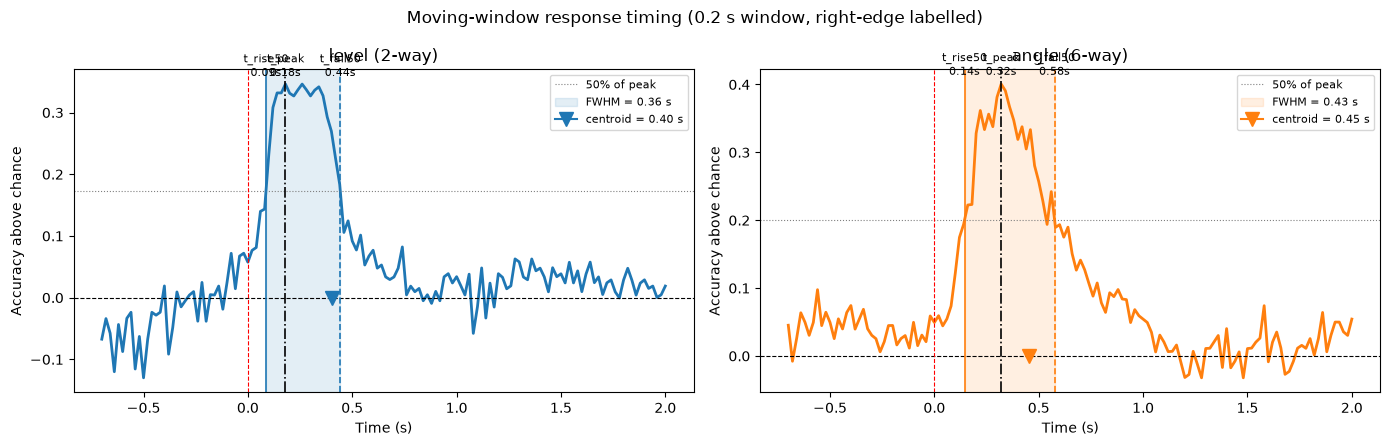

In [68]:
# --- Timing metrics for the two moving-window curves -------------------------
# Work on fold-mean ACCURACY-ABOVE-CHANCE (acc - chance), not the peak-normalised
# curve: landmarks are taken at fractions of each curve's OWN peak, so the shape
# is what matters, but keeping real units avoids peak-normalisation rescaling the
# baseline noise differently for the two curves.
#
# Landmarks (all linearly interpolated between the step_bin grid points -> sub-
# 0.02 s resolution):
#   t_rise50 - first upward crossing of 50 % of own peak
#   t_peak   - argmax  (noisiest: the 0.2 s window flattens the top)
#   t_fall50 - last downward crossing of 50 % of own peak  (NOT assumed = t_rise50)
#   fwhm     - t_fall50 - t_rise50, time spent above half-max
#   centroid - sum(t * f) / sum(f) over a fixed window, f clipped at 0: a
#              threshold-free "where is the mass of the response"
#
# The moving-window label is the RIGHT EDGE of the 0.2 s window, so every absolute
# latency is biased ~0.2 s late. That bias is identical for both curves, so the
# DIFFERENCES (angle - level) are what these numbers are good for.

def _interp_cross(t, y, level, rising=True):
    """Interpolated time at which y crosses `level`.
    rising=True  -> first upward crossing; rising=False -> last downward crossing.
    Returns np.nan if it never crosses."""
    s = (y >= level).astype(int)
    steps = np.diff(s)
    idx = np.where(steps == (1 if rising else -1))[0]
    if idx.size == 0:
        return np.nan
    i = idx[0] if rising else idx[-1]          # segment [i, i+1] holds the crossing
    y0, y1 = y[i], y[i + 1]
    frac = 0.0 if y1 == y0 else (level - y0) / (y1 - y0)
    return t[i] + frac * (t[i + 1] - t[i])


def timing_metrics(t, curve, frac=0.5, com_window=(0.0, 1.5)):
    """t: window times (s, rel. onset). curve: fold-mean accuracy-above-chance."""
    peak = curve.max()
    lvl = frac * peak
    t_rise = _interp_cross(t, curve, lvl, rising=True)
    t_fall = _interp_cross(t, curve, lvl, rising=False)
    t_peak = t[int(np.argmax(curve))]
    m = (t >= com_window[0]) & (t <= com_window[1])
    f = np.clip(curve[m], 0, None)
    centroid = np.sum(t[m] * f) / np.sum(f)
    return dict(t_rise50=t_rise, t_peak=t_peak, t_fall50=t_fall,
                fwhm=t_fall - t_rise, centroid=centroid)


t_axis = time - 1                       # `time` from moving_window_decoding, onset at 0
curve_level = scores_cont_level.mean(1) - 1 / 2
curve_angle = scores_cont_angle.mean(1) - 1 / 6

m_level = timing_metrics(t_axis, curve_level)
m_angle = timing_metrics(t_axis, curve_angle)
delta = {k: m_angle[k] - m_level[k] for k in m_level}   # angle - level

print(f"{'metric':>10}  {'level':>8}  {'angle':>8}  {'angle-level':>12}")
for k in m_level:
    print(f"{k:>10}  {m_level[k]:8.3f}  {m_angle[k]:8.3f}  {delta[k]:12.3f}")

# --- visualise side by side -------------------------------------------------
fig, axs = plt.subplots(1, 2, figsize=(14, 4.5), sharex=True)

for ax, name, curve, mets, col in [
    (axs[0], "level (2-way)", curve_level, m_level, "tab:blue"),
    (axs[1], "angle (6-way)", curve_angle, m_angle, "tab:orange"),
]:
    peak = curve.max()
    ax.plot(t_axis, curve, c=col, lw=2)
    ax.axhline(0, c="k", ls="--", lw=0.8)
    ax.axhline(0.5 * peak, c="grey", ls=":", lw=0.8, label="50% of peak")
    ax.axvline(0, c="r", ls="--", lw=0.8)
    ax.axvspan(mets["t_rise50"], mets["t_fall50"], color=col, alpha=0.12,
               label=f"FWHM = {mets['fwhm']:.2f} s")
    for key, style in [("t_rise50", dict(c=col, ls="-")),
                       ("t_peak", dict(c="k", ls="-.")),
                       ("t_fall50", dict(c=col, ls="--"))]:
        ax.axvline(mets[key], lw=1.2, **style)
        ax.text(mets[key], peak * 1.02, f"{key}\n{mets[key]:.2f}s",
                ha="center", va="bottom", fontsize=8)
    ax.plot(mets["centroid"], 0, marker="v", ms=10, c=col, clip_on=False,
            label=f"centroid = {mets['centroid']:.2f} s")
    ax.set_title(name)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Accuracy above chance")
    ax.legend(loc="upper right", fontsize=8)

fig.suptitle("Moving-window response timing (0.2 s window, right-edge labelled)")
fig.tight_layout()


In [ ]:
# --- N-repeat stratified-shuffle moving-window decoding, PAIRED folds -----
# The plain moving_window_decoding call uses cv=5 -> KFold(shuffle=False), which
# is deterministic: reseeding does nothing. Here we pass explicit shuffled folds
# and average the fold-mean curve over N_REPEATS seeds to smooth the arbitrary
# partition noise so the landmark crossings are stable.
#
# PAIRED SPLITS: the level and angle decoders must see the SAME train/test
# partition each seed, otherwise the CV-partition noise does not cancel in
# delta(angle - level). We build the folds ONCE per seed, stratified on the 12
# solenoid CODES (= level x angle, orthogonal factors here), so every fold stays
# balanced for both labels, then hand the identical split list to both decodes.
# It must be a list, not a generator: moving_window_decoding re-iterates `cv`
# once per time window.
#
# IMPORTANT: the spread across repeats is re-partition variance of the SAME
# trials, not independent samples -- it is NOT a confidence interval. Use it only
# to judge how stable each landmark is. Real uncertainty = trial subsampling +
# across-session signed-rank.

from sklearn.model_selection import StratifiedKFold

N_REPEATS = 20
N_SPLITS = 5

Xr = X_kept[:, resp_sl, :]
y_level = d["ep_level"][keep]
y_angle = d["ep_angle"][keep]
y_code = d["ep_code"][keep]          # 12 classes; stratify on this -> paired folds

rep_level, rep_angle = [], []
for seed in range(N_REPEATS):
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=seed)
    splits = list(skf.split(Xr, y_code))            # SAME folds for both labels
    sl, tt = decode.moving_window_decoding(
        Xr, y_level, window_length_bin=20, step_bin=2, cv=splits)
    sa, _ = decode.moving_window_decoding(
        Xr, y_angle, window_length_bin=20, step_bin=2, cv=splits)
    rep_level.append(sl.mean(1) - 1 / 2)            # fold-mean, above chance
    rep_angle.append(sa.mean(1) - 1 / 6)

rep_level = np.asarray(rep_level)                   # (N_REPEATS, n_windows)
rep_angle = np.asarray(rep_angle)
t_axis = tt - 1                                     # onset-relative window times

# average over repeats -> the curve we extract landmarks from
curve_level_avg = rep_level.mean(0)
curve_angle_avg = rep_angle.mean(0)

m_level_avg = timing_metrics(t_axis, curve_level_avg)
m_angle_avg = timing_metrics(t_axis, curve_angle_avg)
delta_avg = {k: m_angle_avg[k] - m_level_avg[k] for k in m_level_avg}

# per-repeat landmarks (stability only, NOT a CI)
mets_level_rep = [timing_metrics(t_axis, c) for c in rep_level]
mets_angle_rep = [timing_metrics(t_axis, c) for c in rep_angle]
METRICS = ["t_rise50", "t_peak", "t_fall50", "fwhm", "centroid"]

print(f"{N_REPEATS} repeats x {N_SPLITS}-fold stratified shuffle, folds stratified on "
      f"ep_code and shared by both decoders")
print(f"{'metric':>10}  {'level':>8}  {'angle':>8}  {'angle-level':>12}   (repeat sd L / A)")
for k in METRICS:
    sdL = np.std([m[k] for m in mets_level_rep])
    sdA = np.std([m[k] for m in mets_angle_rep])
    print(f"{k:>10}  {m_level_avg[k]:8.3f}  {m_angle_avg[k]:8.3f}  {delta_avg[k]:12.3f}"
          f"   ({sdL:.3f} / {sdA:.3f})")

# --- overlay the two averaged curves with their landmarks -----------------
fig, ax = plt.subplots(figsize=(11, 5))
for name, curve, rep, mets, col in [
    ("level (2-way)", curve_level_avg, rep_level, m_level_avg, "tab:blue"),
    ("angle (6-way)", curve_angle_avg, rep_angle, m_angle_avg, "tab:orange"),
]:
    ax.plot(t_axis, rep.T, c=col, lw=0.4, alpha=0.25)          # individual repeats
    ax.plot(t_axis, curve, c=col, lw=2.5, label=name)          # repeat-average
    peak = curve.max()
    ax.axhline(0.5 * peak, c=col, ls=":", lw=0.8)
    ax.axvspan(mets["t_rise50"], mets["t_fall50"], color=col, alpha=0.08)
    for key, ls in [("t_rise50", "-"), ("t_peak", "-."), ("t_fall50", "--")]:
        ax.axvline(mets[key], c=col, ls=ls, lw=1.2)
    ax.plot(mets["centroid"], 0, marker="v", ms=11, c=col, clip_on=False)
ax.axhline(0, c="k", ls="--", lw=0.8)
ax.axvline(0, c="r", ls="--", lw=0.8, label="perturb")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Accuracy above chance")
ax.set_title(
    f"Moving-window curves, {N_REPEATS}x{N_SPLITS}-fold stratified-shuffle average (paired folds)\n"
    "solid = repeat-average, thin = individual repeats;  "
    "| t_rise50   -.- t_peak   --- t_fall50   v centroid"
)
ax.legend(loc="upper right")
fig.tight_layout()


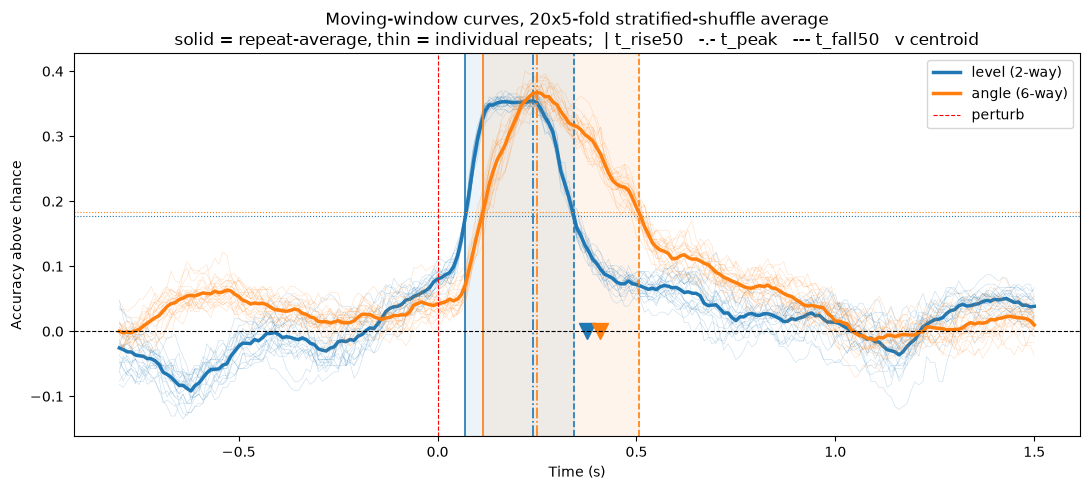

In [70]:
# --- overlay the two averaged curves with their landmarks -----------------
fig, ax = plt.subplots(figsize=(11, 5))
for name, curve, rep, mets, col in [
    ("level (2-way)", curve_level_avg, rep_level, m_level_avg, "tab:blue"),
    ("angle (6-way)", curve_angle_avg, rep_angle, m_angle_avg, "tab:orange"),
]:
    ax.plot(t_axis, rep.T, c=col, lw=0.4, alpha=0.25)          # individual repeats
    ax.plot(t_axis, curve, c=col, lw=2.5, label=name)          # repeat-average
    peak = curve.max()
    ax.axhline(0.5 * peak, c=col, ls=":", lw=0.8)
    ax.axvspan(mets["t_rise50"], mets["t_fall50"], color=col, alpha=0.08)
    for key, ls in [("t_rise50", "-"), ("t_peak", "-."), ("t_fall50", "--")]:
        ax.axvline(mets[key], c=col, ls=ls, lw=1.2)
    ax.plot(mets["centroid"], 0, marker="v", ms=11, c=col, clip_on=False)
ax.axhline(0, c="k", ls="--", lw=0.8)
ax.axvline(0, c="r", ls="--", lw=0.8, label="perturb")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Accuracy above chance")
ax.set_title(
    f"Moving-window curves, {N_REPEATS}x{N_SPLITS}-fold stratified-shuffle average\n"
    "solid = repeat-average, thin = individual repeats;  "
    "| t_rise50   -.- t_peak   --- t_fall50   v centroid"
)
ax.legend(loc="upper right")
fig.tight_layout()

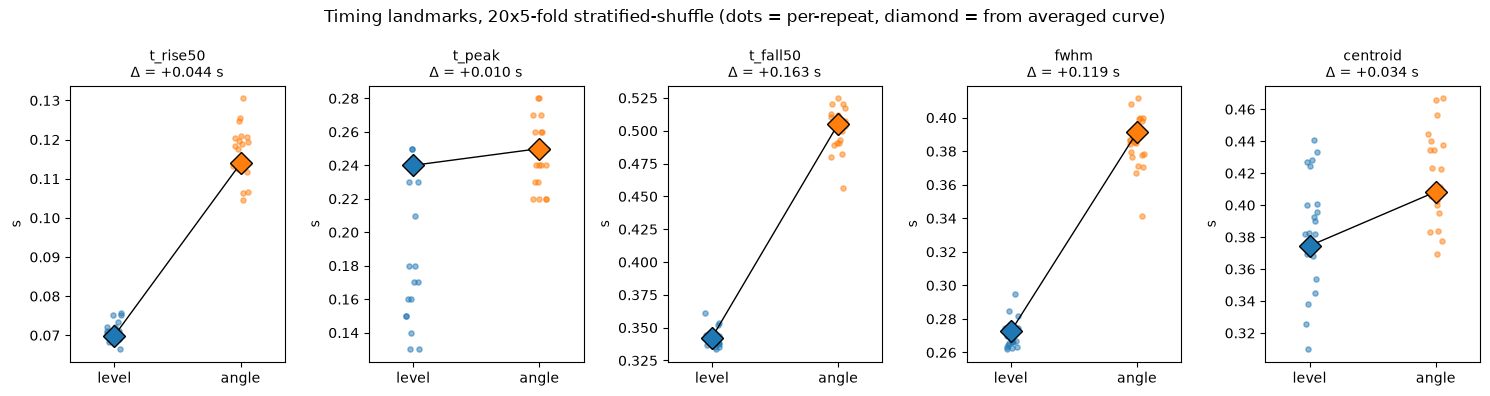

In [71]:
# --- each timing metric on its own axis ----------------------------------
# Big diamond = landmark from the repeat-AVERAGED curve (the number we report).
# Small dots  = landmark computed per repeat (spread = partition stability,
#               NOT a confidence interval).
fig, axs = plt.subplots(1, len(METRICS), figsize=(3.0 * len(METRICS), 4))
_jit = np.random.default_rng(0)
for ax, k in zip(axs, METRICS):
    for x0, rep_mets, avg_mets, col in [
        (0, mets_level_rep, m_level_avg, "tab:blue"),
        (1, mets_angle_rep, m_angle_avg, "tab:orange"),
    ]:
        vals = np.array([m[k] for m in rep_mets])
        ax.scatter(x0 + _jit.uniform(-0.06, 0.06, vals.size), vals,
                   s=14, c=col, alpha=0.5)
        ax.plot(x0, avg_mets[k], marker="D", ms=11, c=col, mec="k", zorder=5)
    ax.plot([0, 1], [m_level_avg[k], m_angle_avg[k]], c="k", lw=1, zorder=4)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["level", "angle"])
    ax.set_xlim(-0.35, 1.35)
    ax.set_title(f"{k}\n$\\Delta$ = {delta_avg[k]:+.3f} s", fontsize=10)
    ax.set_ylabel("s")
fig.suptitle(
    f"Timing landmarks, {N_REPEATS}x{N_SPLITS}-fold stratified-shuffle "
    "(dots = per-repeat, diamond = from averaged curve)"
)
fig.tight_layout()


grid spacing = 10 ms
    metric | lvl interp  lvl grid | ang interp  ang grid |  d interp   d grid
  t_rise50 |      0.070     0.070 |      0.114     0.120 |     0.044    0.050
    t_peak |      0.240     0.240 |      0.250     0.250 |     0.010    0.010
  t_fall50 |      0.342     0.340 |      0.505     0.500 |     0.163    0.160
      fwhm |      0.273     0.270 |      0.391     0.380 |     0.119    0.110
  centroid |      0.375     0.375 |      0.408     0.408 |     0.034    0.034


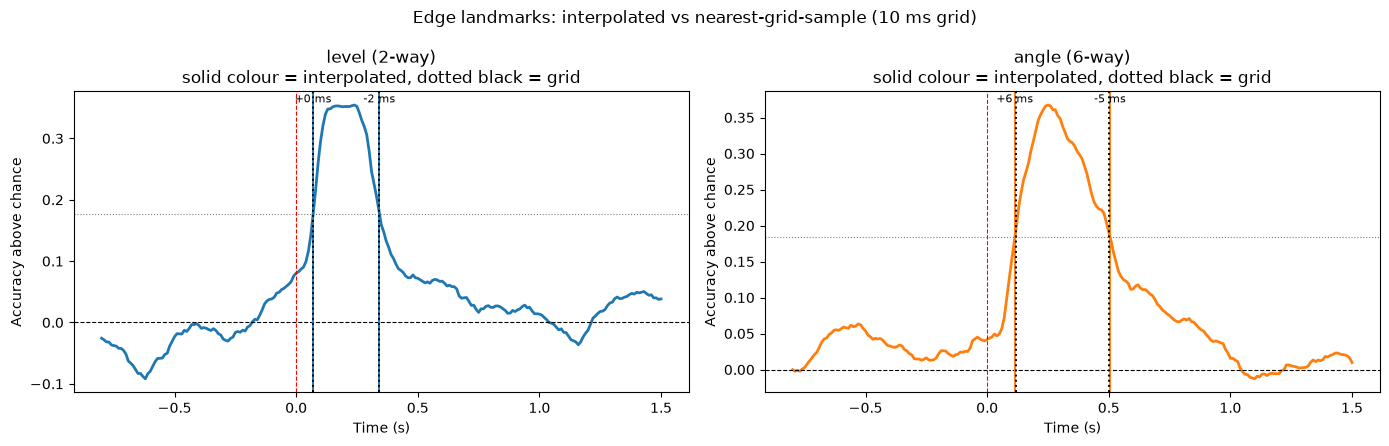

In [72]:
# --- No-interpolation variant of the edge landmarks, for comparison -------
# `_interp_cross` linearly interpolates the threshold crossing inside the 0.02 s
# grid bracket. Here we instead snap to grid samples: rising -> first sample at
# or above 0.5*peak; falling -> last sample at or above it. This isolates the
# interpolation effect -- same repeat-averaged curves, same grid, only the
# crossing rule changes. Only t_rise50 / t_fall50 / fwhm can differ; t_peak
# (argmax) and centroid (weighted sum) never used interpolation and are identical.

def _grid_cross(t, y, level, rising=True):
    s = (y >= level).astype(int)
    steps = np.diff(s)
    idx = np.where(steps == (1 if rising else -1))[0]
    if idx.size == 0:
        return np.nan
    i = idx[0] if rising else idx[-1]
    return t[i + 1] if rising else t[i]      # first / last grid sample >= level


def timing_metrics_grid(t, curve, frac=0.5, com_window=(0.0, 1.5)):
    peak = curve.max()
    lvl = frac * peak
    t_rise = _grid_cross(t, curve, lvl, rising=True)
    t_fall = _grid_cross(t, curve, lvl, rising=False)
    t_peak = t[int(np.argmax(curve))]
    m = (t >= com_window[0]) & (t <= com_window[1])
    f = np.clip(curve[m], 0, None)
    centroid = np.sum(t[m] * f) / np.sum(f)
    return dict(t_rise50=t_rise, t_peak=t_peak, t_fall50=t_fall,
                fwhm=t_fall - t_rise, centroid=centroid)


g_level = timing_metrics_grid(t_axis, curve_level_avg)
g_angle = timing_metrics_grid(t_axis, curve_angle_avg)
delta_grid = {k: g_angle[k] - g_level[k] for k in g_level}

grid_ms = np.round(np.median(np.diff(t_axis)) * 1000, 1)
print(f"grid spacing = {grid_ms:.0f} ms")
print(f"{'metric':>10} | {'lvl interp':>10} {'lvl grid':>9} | "
      f"{'ang interp':>10} {'ang grid':>9} | {'d interp':>9} {'d grid':>8}")
for k in METRICS:
    print(f"{k:>10} | {m_level_avg[k]:10.3f} {g_level[k]:9.3f} | "
          f"{m_angle_avg[k]:10.3f} {g_angle[k]:9.3f} | "
          f"{delta_avg[k]:9.3f} {delta_grid[k]:8.3f}")

# --- show the landmark shift on the two curves ---------------------------
fig, axs = plt.subplots(1, 2, figsize=(14, 4.5), sharex=True)
for ax, name, curve, mi, mg, col in [
    (axs[0], "level (2-way)", curve_level_avg, m_level_avg, g_level, "tab:blue"),
    (axs[1], "angle (6-way)", curve_angle_avg, m_angle_avg, g_angle, "tab:orange"),
]:
    peak = curve.max()
    ax.plot(t_axis, curve, c=col, lw=2)
    ax.axhline(0.5 * peak, c="grey", ls=":", lw=0.8)
    ax.axhline(0, c="k", ls="--", lw=0.8)
    ax.axvline(0, c="r", ls="--", lw=0.8)
    for key in ("t_rise50", "t_fall50"):
        ax.axvline(mi[key], c=col, ls="-", lw=1.4)
        ax.axvline(mg[key], c="k", ls=":", lw=1.4)
        ax.annotate(f"{(mg[key] - mi[key]) * 1000:+.0f} ms", (mi[key], peak),
                    fontsize=8, ha="center", va="bottom")
    ax.set_title(f"{name}\nsolid colour = interpolated, dotted black = grid")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Accuracy above chance")
fig.suptitle("Edge landmarks: interpolated vs nearest-grid-sample "
             f"({grid_ms:.0f} ms grid)")
fig.tight_layout()


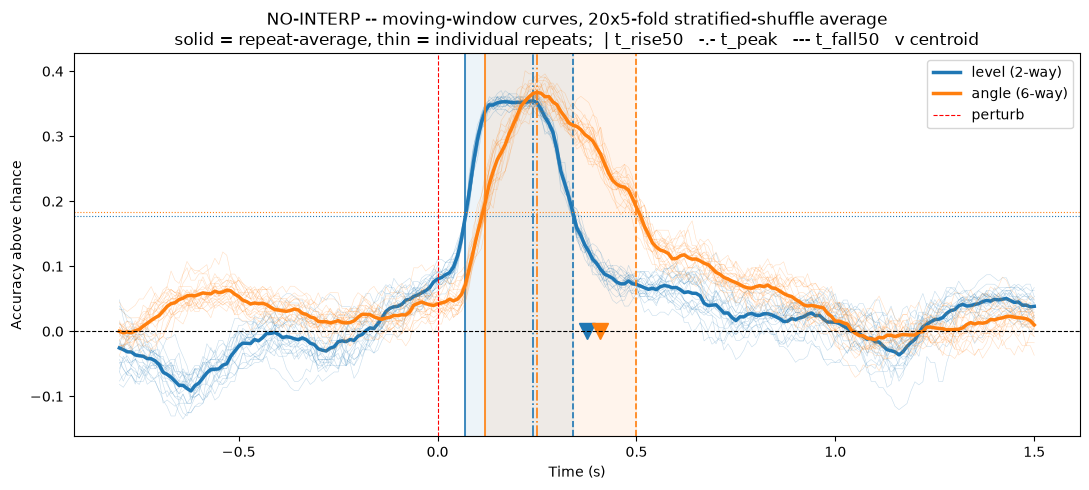

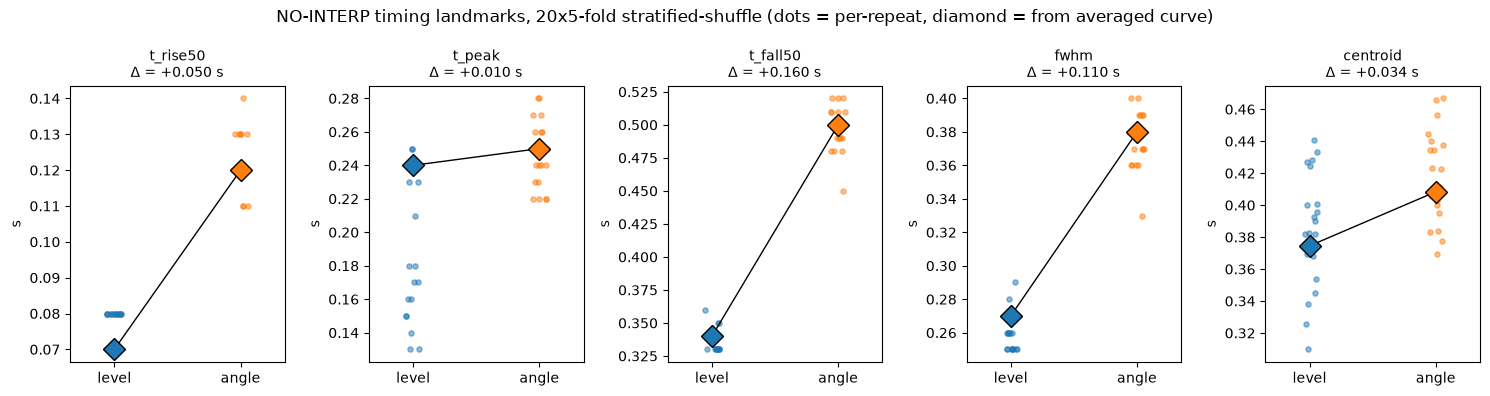

In [73]:
# --- Same two plots as above, but with the NO-INTERPOLATION landmarks -----
# Uses timing_metrics_grid (nearest grid sample, no linear crossing) on the same
# repeat-averaged curves and the same per-repeat curves. Compare panel-for-panel
# with the interpolated versions above; grid landmarks are quantised to the
# 0.02 s step so the per-repeat dots pile up on a few levels.

mets_level_rep_grid = [timing_metrics_grid(t_axis, c) for c in rep_level]
mets_angle_rep_grid = [timing_metrics_grid(t_axis, c) for c in rep_angle]

# 1. overlay the two averaged curves with their grid landmarks
fig, ax = plt.subplots(figsize=(11, 5))
for name, curve, rep, mets, col in [
    ("level (2-way)", curve_level_avg, rep_level, g_level, "tab:blue"),
    ("angle (6-way)", curve_angle_avg, rep_angle, g_angle, "tab:orange"),
]:
    ax.plot(t_axis, rep.T, c=col, lw=0.4, alpha=0.25)          # individual repeats
    ax.plot(t_axis, curve, c=col, lw=2.5, label=name)          # repeat-average
    peak = curve.max()
    ax.axhline(0.5 * peak, c=col, ls=":", lw=0.8)
    ax.axvspan(mets["t_rise50"], mets["t_fall50"], color=col, alpha=0.08)
    for key, ls in [("t_rise50", "-"), ("t_peak", "-."), ("t_fall50", "--")]:
        ax.axvline(mets[key], c=col, ls=ls, lw=1.2)
    ax.plot(mets["centroid"], 0, marker="v", ms=11, c=col, clip_on=False)
ax.axhline(0, c="k", ls="--", lw=0.8)
ax.axvline(0, c="r", ls="--", lw=0.8, label="perturb")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Accuracy above chance")
ax.set_title(
    f"NO-INTERP -- moving-window curves, {N_REPEATS}x{N_SPLITS}-fold stratified-shuffle average\n"
    "solid = repeat-average, thin = individual repeats;  "
    "| t_rise50   -.- t_peak   --- t_fall50   v centroid"
)
ax.legend(loc="upper right")
fig.tight_layout()

# 2. each timing metric on its own axis (grid landmarks)
fig, axs = plt.subplots(1, len(METRICS), figsize=(3.0 * len(METRICS), 4))
_jit = np.random.default_rng(0)
for ax, k in zip(axs, METRICS):
    for x0, rep_mets, avg_mets, col in [
        (0, mets_level_rep_grid, g_level, "tab:blue"),
        (1, mets_angle_rep_grid, g_angle, "tab:orange"),
    ]:
        vals = np.array([m[k] for m in rep_mets])
        ax.scatter(x0 + _jit.uniform(-0.06, 0.06, vals.size), vals,
                   s=14, c=col, alpha=0.5)
        ax.plot(x0, avg_mets[k], marker="D", ms=11, c=col, mec="k", zorder=5)
    ax.plot([0, 1], [g_level[k], g_angle[k]], c="k", lw=1, zorder=4)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["level", "angle"])
    ax.set_xlim(-0.35, 1.35)
    ax.set_title(f"{k}\n$\\Delta$ = {delta_grid[k]:+.3f} s", fontsize=10)
    ax.set_ylabel("s")
fig.suptitle(
    f"NO-INTERP timing landmarks, {N_REPEATS}x{N_SPLITS}-fold stratified-shuffle "
    "(dots = per-repeat, diamond = from averaged curve)"
)
fig.tight_layout()


### All sessions

In [79]:
resp_sl

slice(100, 350, None)

In [80]:
# ============================================================================
# Across-session moving-window response timing
# ----------------------------------------------------------------------------
# Runs the paired-fold repeated decoding (same recipe as the single-session
# cells above) for every session, and saves per-session curves + NO-INTERP
# landmark metrics to disk. No report, no figures -- just arrays, to play with
# later. Results also stay in memory as `session_results` / `summary_rows`.
#
# Params: identical to the single-session pipeline
#   N_REPEATS=20, N_SPLITS=5, window_length_bin=WINDOW_LENGTH_BIN, paired folds
# EXCEPT step_bin=1 (10 ms grid). Response window = `resp_sl` as defined above
# (RESPONSE). WINDOW_LENGTH_BIN is set to the pipeline value 20 (= 0.2 s at
# FS=100); the scratch cell higher up uses 30 -- change the one line if you
# meant 0.3 s.
#
# Fold stratification: prefer the 12 solenoid CODES so every fold is balanced
# for BOTH level and angle. Some sessions have a code class with < N_SPLITS
# trials (M063: min 1; M103_02_19: min 4). There we fall back to the finest
# label that still has >= N_SPLITS per class (code -> angle -> level -> plain
# KFold), recorded per session as `strat_on`.
# ============================================================================
import csv
import json
import time as _time
from pathlib import Path
from sklearn.model_selection import StratifiedKFold, KFold

# ---- config -------------------------------------------------------------
N_REPEATS = 20
N_SPLITS = 5
WINDOW_LENGTH_BIN = 20          # 0.2 s at FS=100 (single-session pipeline value)
STEP_BIN = 1                    # 10 ms grid -- this run's only deviation
CHANCE = {"level": 1 / 2, "angle": 1 / 6}
METRICS = ["t_rise50", "t_peak", "t_fall50", "fwhm", "centroid"]

CACHE_DIR = Path("/mnt/datascience/workspaces/"
                 "mesparza-40inbrain-2dneuroelectronics-2ecom/"
                 "equake-interim-results/cache")
OUT_DIR = Path(Params.ACROSS_SESSION_RESULTS_DIR) / "moving-window-response-timing"
OUT_DIR.mkdir(parents=True, exist_ok=True)

session_files = sorted(CACHE_DIR.glob("*.npz"))   # the canonical 11 (= ALL_SESSIONS)
print(f"{len(session_files)} sessions  ->  {OUT_DIR}\n")


def _pick_strat(y_code, y_angle, y_level, n_splits):
    """Finest label whose smallest class still has >= n_splits members."""
    for name, y in [("code", y_code), ("angle", y_angle), ("level", y_level)]:
        _, counts = np.unique(y, return_counts=True)
        if counts.min() >= n_splits:
            return name, y
    return "none", None                            # -> plain KFold


def _metric_vec(mets):
    return np.array([mets[k] for k in METRICS], float)


session_results = {}           # {session: dict of arrays}  -- stays in memory
summary_rows = []

for f in session_files:
    t0 = _time.time()
    dsess = np.load(f, allow_pickle=True)          # `dsess` so we don't clobber `d`
    session = str(dsess["session"])

    Xz = dsess["ep_X"]                             # no baseline z-score (matches pipeline)
    keep = drop_by_perturb_score(dsess["ep_perturb_score"], stat="sem", verbose=False)
    Xr = Xz[keep][:, resp_sl, :]
    y_level = dsess["ep_level"][keep]
    y_angle = dsess["ep_angle"][keep]
    y_code = dsess["ep_code"][keep]

    strat_on, y_strat = _pick_strat(y_code, y_angle, y_level, N_SPLITS)

    rep_level, rep_angle = [], []
    for seed in range(N_REPEATS):
        if strat_on == "none":
            splits = list(KFold(N_SPLITS, shuffle=True, random_state=seed).split(Xr))
        else:
            splits = list(StratifiedKFold(N_SPLITS, shuffle=True, random_state=seed)
                          .split(Xr, y_strat))     # SAME folds for both labels
        sl, tt = decode.moving_window_decoding(
            Xr, y_level, window_length_bin=WINDOW_LENGTH_BIN, step_bin=STEP_BIN, cv=splits)
        sa, _ = decode.moving_window_decoding(
            Xr, y_angle, window_length_bin=WINDOW_LENGTH_BIN, step_bin=STEP_BIN, cv=splits)
        rep_level.append(sl.mean(1) - CHANCE["level"])   # fold-mean, above chance
        rep_angle.append(sa.mean(1) - CHANCE["angle"])

    rep_level = np.asarray(rep_level)              # (N_REPEATS, n_windows)
    rep_angle = np.asarray(rep_angle)
    t_axis = tt + RESPONSE[0]                      # window right-edge, onset-relative

    curve_level_avg = rep_level.mean(0)
    curve_angle_avg = rep_angle.mean(0)

    # NO-INTERPOLATION landmarks (timing_metrics_grid from the cell above)
    g_level_avg = timing_metrics_grid(t_axis, curve_level_avg)
    g_angle_avg = timing_metrics_grid(t_axis, curve_angle_avg)
    g_delta_avg = {k: g_angle_avg[k] - g_level_avg[k] for k in METRICS}
    g_level_rep = np.array([_metric_vec(timing_metrics_grid(t_axis, c)) for c in rep_level])
    g_angle_rep = np.array([_metric_vec(timing_metrics_grid(t_axis, c)) for c in rep_angle])

    res = dict(
        session=session,
        t_axis=t_axis,
        rep_level=rep_level, rep_angle=rep_angle,          # accuracy above chance, per repeat
        curve_level_avg=curve_level_avg, curve_angle_avg=curve_angle_avg,
        metric_names=np.array(METRICS),
        grid_level_avg=_metric_vec(g_level_avg),           # landmark from repeat-avg curve
        grid_angle_avg=_metric_vec(g_angle_avg),
        grid_delta_avg=np.array([g_delta_avg[k] for k in METRICS]),
        grid_level_rep=g_level_rep, grid_angle_rep=g_angle_rep,   # (N_REPEATS, 5) per-repeat
        n_trials_kept=int(keep.sum()), n_trials_total=int(keep.size),
        strat_on=strat_on,
        n_repeats=N_REPEATS, n_splits=N_SPLITS,
        window_length_bin=WINDOW_LENGTH_BIN, step_bin=STEP_BIN,
        bin_size=1.0 / FS, response_window=np.array(RESPONSE, float),
        chance_level=CHANCE["level"], chance_angle=CHANCE["angle"],
    )
    session_results[session] = res
    np.savez_compressed(OUT_DIR / f"{session}.npz", **res)

    summary_rows.append(dict(
        session=session, strat_on=strat_on, n_kept=res["n_trials_kept"],
        **{f"{k}_level": g_level_avg[k] for k in METRICS},
        **{f"{k}_angle": g_angle_avg[k] for k in METRICS},
        **{f"{k}_delta": g_delta_avg[k] for k in METRICS},
    ))
    print(f"  {session:26s}  kept {res['n_trials_kept']:3d}/{res['n_trials_total']:3d}  "
          f"strat={strat_on:5s}  fwhm d={g_delta_avg['fwhm']:+.3f}  "
          f"fall d={g_delta_avg['t_fall50']:+.3f}  ({_time.time() - t0:.0f}s)")

# ---- summary table + params sidecar -----------------------------------
_cols = (["session", "strat_on", "n_kept"]
         + [f"{k}_{w}" for w in ("level", "angle", "delta") for k in METRICS])
with open(OUT_DIR / "summary_metrics.csv", "w", newline="") as fh:
    wr = csv.DictWriter(fh, fieldnames=_cols)
    wr.writeheader()
    wr.writerows(summary_rows)

with open(OUT_DIR / "params.json", "w") as fh:
    json.dump(dict(
        n_repeats=N_REPEATS, n_splits=N_SPLITS, window_length_bin=WINDOW_LENGTH_BIN,
        step_bin=STEP_BIN, bin_size=1.0 / FS, response_window=list(RESPONSE),
        chance=CHANCE, metrics=METRICS,
        landmark_extraction="grid / no interpolation (timing_metrics_grid)",
        strat_preference=["code", "angle", "level", "KFold"],
        cache_dir=str(CACHE_DIR),
        sessions=[s for s in session_results],
    ), fh, indent=2)

print(f"\nsaved {len(session_results)} session .npz + summary_metrics.csv + params.json\n  -> {OUT_DIR}")


11 sessions  ->  /mnt/datascience/workspaces/mesparza-40inbrain-2dneuroelectronics-2ecom/equake-interim-results/moving-window-response-timing



100%|██████████| 231/231 [00:03<00:00, 64.57it/s]


  M061_2025_03_04_10_00       kept 203/243  strat=code   fwhm d=+0.050  fall d=+0.100  (133s)


100%|██████████| 231/231 [00:02<00:00, 78.83it/s]


  M061_2025_03_05_14_00       kept 107/149  strat=code   fwhm d=+0.070  fall d=+0.120  (110s)


100%|██████████| 231/231 [00:03<00:00, 66.63it/s]


  M061_2025_03_06_14_00       kept 208/244  strat=code   fwhm d=+0.120  fall d=+0.160  (132s)


100%|██████████| 231/231 [00:03<00:00, 67.09it/s]


  M062_2025_03_20_14_00       kept 186/260  strat=code   fwhm d=+0.050  fall d=+0.120  (129s)


100%|██████████| 231/231 [00:03<00:00, 60.86it/s]


  M062_2025_03_21_14_00       kept 222/304  strat=code   fwhm d=+0.030  fall d=+0.100  (136s)


100%|██████████| 231/231 [00:02<00:00, 84.27it/s]


  M063_2025_03_13_14_00       kept  60/ 91  strat=angle  fwhm d=+1.100  fall d=+1.170  (102s)


100%|██████████| 231/231 [00:03<00:00, 62.59it/s]


  M078_2025_08_06_15_00       kept 225/280  strat=code   fwhm d=+0.010  fall d=+0.080  (145s)


100%|██████████| 231/231 [00:03<00:00, 62.58it/s]


  M086_2025_12_10_15_00       kept 242/277  strat=code   fwhm d=+0.310  fall d=+0.350  (140s)


100%|██████████| 231/231 [00:03<00:00, 71.67it/s]


  M103_2026_02_18_15_30       kept 154/220  strat=code   fwhm d=+0.050  fall d=+0.110  (120s)


100%|██████████| 231/231 [00:03<00:00, 76.56it/s]


  M103_2026_02_19_15_30       kept 132/228  strat=angle  fwhm d=+0.150  fall d=+0.190  (115s)


100%|██████████| 231/231 [00:03<00:00, 64.74it/s]

  M106_2026_02_25_15_00       kept 212/312  strat=code   fwhm d=+0.120  fall d=+0.190  (132s)

saved 11 session .npz + summary_metrics.csv + params.json
  -> /mnt/datascience/workspaces/mesparza-40inbrain-2dneuroelectronics-2ecom/equake-interim-results/moving-window-response-timing


### Load results

In [3]:
DATA_DIR = Path('/mnt/datascience/workspaces/mesparza-40inbrain-2dneuroelectronics-2ecom/equake-interim-results/moving-window-response-timing')
npz_files = sorted(DATA_DIR.glob('*.npz'))
npz_files
for f in npz_files:
    d = np.load(f, allow_pickle=True)

In [6]:
for k in d.keys():
    print(k)

session
t_axis
rep_level
rep_angle
curve_level_avg
curve_angle_avg
metric_names
grid_level_avg
grid_angle_avg
grid_delta_avg
grid_level_rep
grid_angle_rep
n_trials_kept
n_trials_total
strat_on
n_repeats
n_splits
window_length_bin
step_bin
bin_size
response_window
chance_level
chance_angle


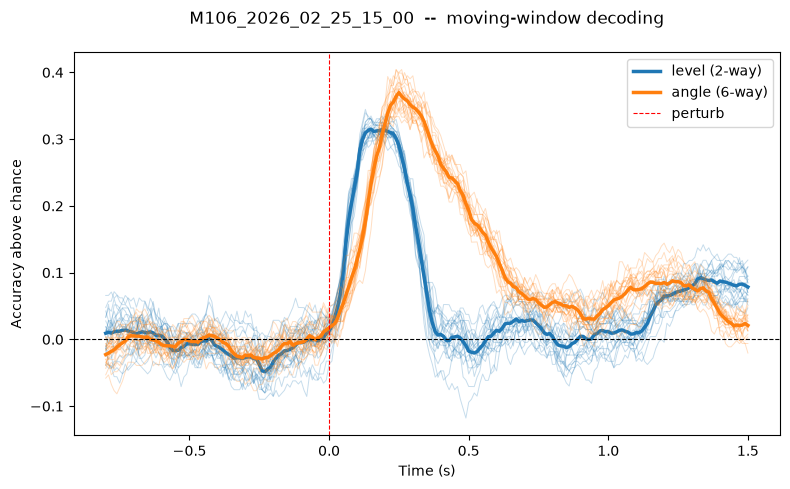

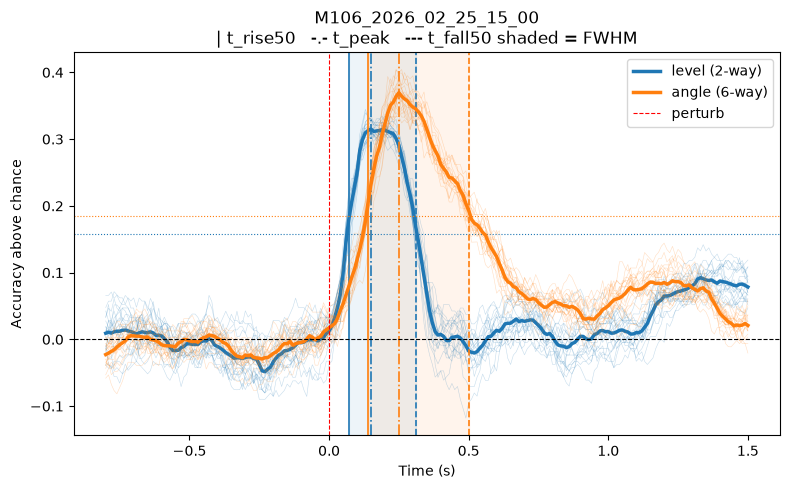

In [39]:
# Example traces for one loaded session `d` (from the load-results cell above;
# it leaves `d` as the last file -- to pick another, e.g.
#   d = np.load(DATA_DIR / "M061_2025_03_06_14_00.npz", allow_pickle=True)
# rep_level / rep_angle are fold-mean ACCURACY ABOVE CHANCE, one row per repeat.

t = d["t_axis"]
mnames = list(d["metric_names"])
sess = str(d["session"])

# ---- 1. plain: mean curve + repetitions, no metrics --------------------
fig, ax = plt.subplots(figsize=(8, 5))
for name, rep, col in [
    ("level (2-way)", d["rep_level"], "tab:blue"),
    ("angle (6-way)", d["rep_angle"], "tab:orange"),
]:
    ax.plot(t, rep.T, c=col, lw=0.7, alpha=0.25)          # individual repeats
    ax.plot(t, rep.mean(0), c=col, lw=2.5, label=name)    # repeat-average
ax.axhline(0, c="k", ls="--", lw=0.8)
ax.axvline(0, c="r", ls="--", lw=0.8, label="perturb")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Accuracy above chance")
ax.set_title(f"{sess}  --  moving-window decoding\n")
ax.legend(loc="upper right")
fig.tight_layout()
plt.show()

# ---- 2. same, with the NO-INTERP landmarks painted over ----------------
m_level = dict(zip(mnames, d["grid_level_avg"]))
m_angle = dict(zip(mnames, d["grid_angle_avg"]))

fig, ax = plt.subplots(figsize=(8, 5))
for name, rep, mets, col in [
    ("level (2-way)", d["rep_level"], m_level, "tab:blue"),
    ("angle (6-way)", d["rep_angle"], m_angle, "tab:orange"),
]:
    curve = rep.mean(0)
    ax.plot(t, rep.T, c=col, lw=0.4, alpha=0.25)
    ax.plot(t, curve, c=col, lw=2.5, label=name)
    peak = curve.max()
    ax.axhline(0.5 * peak, c=col, ls=":", lw=0.8)                     # half-max level
    ax.axvspan(mets["t_rise50"], mets["t_fall50"], color=col, alpha=0.08)  # FWHM span
    for key, ls in [("t_rise50", "-"), ("t_peak", "-."), ("t_fall50", "--")]:
        ax.axvline(mets[key], c=col, ls=ls, lw=1.2)
    # ax.plot(mets["centroid"], 0, marker="v", ms=11, c=col, clip_on=False)  # centroid
ax.axhline(0, c="k", ls="--", lw=0.8)
ax.axvline(0, c="r", ls="--", lw=0.8, label="perturb")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Accuracy above chance")
ax.set_title(f"{sess}\n"
             "| t_rise50   -.- t_peak   --- t_fall50 shaded = FWHM")
ax.legend(loc="upper right")
fig.tight_layout()
plt.show()


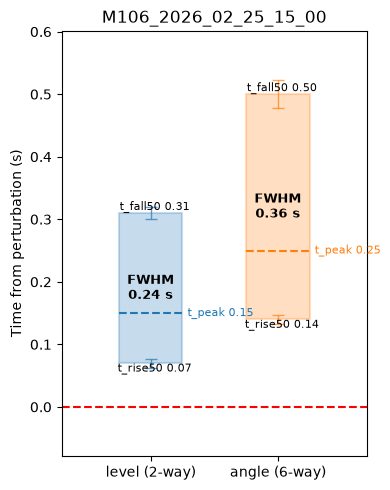

In [61]:
# "Floating bar" summary of the NO-INTERP landmarks for the loaded session `d`.
# One bar per label: it spans t_rise50 (bottom) -> t_fall50 (top), shaded;
# the dashed line inside is t_peak. Caps = +/-1 sd across the repeats
# (partition stability, NOT a confidence interval).

mnames = list(d["metric_names"])
ri, pi, fi = (mnames.index(k) for k in ("t_rise50", "t_peak", "t_fall50"))

bars = [
    ("level (2-way)", d["grid_level_avg"], d["grid_level_rep"], "tab:blue"),
    ("angle (6-way)", d["grid_angle_avg"], d["grid_angle_rep"], "tab:orange"),
]

fig, ax = plt.subplots(figsize=(4, 5))
W = 0.5
for x, (name, avg, rep, col) in enumerate(bars):
    lo, pk, hi = avg[ri], avg[pi], avg[fi]
    if not np.isfinite([lo, pk, hi]).all():
        ax.text(x, 0, f"{name}\nlandmark = nan", ha="center", va="center", color=col)
        continue
    ax.add_patch(plt.Rectangle((x - W / 2, lo), W, hi - lo,
                               facecolor=col, alpha=0.25, edgecolor=col, lw=1.5))
    ax.hlines(pk, x - W / 2, x + W / 2, color=col, ls="--", lw=1.5)          # t_peak
    # +/-1 sd across repeats on the two edges
    for idx, edge in [(ri, lo), (fi, hi)]:
        sd = np.nanstd(rep[:, idx])
        ax.errorbar(x, edge, yerr=sd, color=col, lw=1, capsize=4, alpha=0.7)
    ax.text(x, hi, f"  t_fall50 {hi:.2f}", va="bottom", ha="center", fontsize=8)
    ax.text(x, lo, f"  t_rise50 {lo:.2f}", va="top", ha="center", fontsize=8)
    ax.text(x + W / 2 + 0.04, pk, f"t_peak {pk:.2f}", va="center", ha="left",
            fontsize=8, color=col)
    ax.text(x, (lo + hi) / 2, f"FWHM\n{hi - lo:.2f} s", va="center", ha="center",
            fontsize=9, weight="bold")

ax.axhline(0, c="r", ls="--")                                       # onset
ax.set_xticks([0, 1])
ax.set_xticklabels([b[0] for b in bars])
ax.set_xlim(-0.7, 1.7)
ax.margins(y=0.15)
ax.set_ylabel("Time from perturbation (s)")
ax.set_title(f"{str(d['session'])}")
fig.tight_layout()
plt.show()


10 sessions (excluded ('M063',)): ['M061_2025_03_04_10_00', 'M061_2025_03_05_14_00', 'M061_2025_03_06_14_00', 'M062_2025_03_20_14_00', 'M062_2025_03_21_14_00', 'M078_2025_08_06_15_00', 'M086_2025_12_10_15_00', 'M103_2026_02_18_15_30', 'M103_2026_02_19_15_30', 'M106_2026_02_25_15_00']


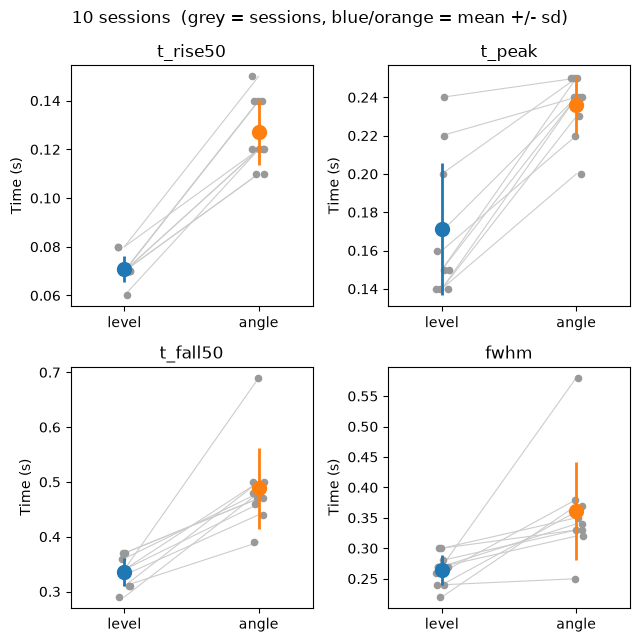

In [59]:
# Across-session summary of the NO-INTERP landmarks: one subplot per metric,
# grey dots = individual sessions (level vs angle, faint line pairs them),
# blue/orange "-o" = mean +/- sd ACROSS SESSIONS. Loads every per-session npz.

RESULTS_DIR = Path("/mnt/datascience/workspaces/"
                   "mesparza-40inbrain-2dneuroelectronics-2ecom/"
                   "equake-interim-results/moving-window-response-timing")
EXCLUDE = ("M063",)          # M063: ~60 trials, needs angle fallback, t_fall50 unreliable

npz_paths = [p for p in sorted(RESULTS_DIR.glob("*.npz"))
             if not any(x in p.name for x in EXCLUDE)]
assert npz_paths, f"no per-session npz in {RESULTS_DIR} -- run the across-session cell first"

sessions, lvl, ang = [], [], []
for p in npz_paths:
    r = np.load(p, allow_pickle=True)
    sessions.append(str(r["session"]))
    mnames = list(r["metric_names"])
    lvl.append(r["grid_level_avg"])
    ang.append(r["grid_angle_avg"])
lvl, ang = np.array(lvl), np.array(ang)          # (n_sessions, 5)
print(f"{len(sessions)} sessions (excluded {EXCLUDE}): {sessions}")

SHOW = ["t_rise50", "t_peak", "t_fall50", "fwhm"]
COL = {"level": "tab:blue", "angle": "tab:orange"}
_rng = np.random.default_rng(0)

fig, axs = plt.subplots(2, 2, figsize=(6.5, 6.5))
axs = axs.flatten()
for ax, k in zip(axs, SHOW):
    j = mnames.index(k)
    vL, vA = lvl[:, j], ang[:, j]
    for i in range(len(sessions)):                       # faint paired lines
        ax.plot([0, 1], [vL[i], vA[i]], c="0.8", lw=0.8, zorder=1)
    for a, v in [(0, vL), (1, vA)]:                      # individual sessions stay grey
        ax.scatter(a + _rng.uniform(-0.05, 0.05, v.size), v, s=20, c="0.6", zorder=2)
    # mean +/- sd across sessions
    mL, mA = np.nanmean(vL), np.nanmean(vA)
    # ax.plot([0, 1], [mL, mA], "-", c="0.3", lw=1.5, zorder=3)
    ax.errorbar(0, mL, yerr=np.nanstd(vL), fmt="o", c=COL["level"], capsize=0, lw=2, zorder=4, ms=10)
    ax.errorbar(1, mA, yerr=np.nanstd(vA), fmt="o", c=COL["angle"], capsize=0, lw=2, zorder=4, ms=10)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["level", "angle"])
    ax.set_xlim(-0.4, 1.4)
    ax.set_title(k)
    ax.set_ylabel("Time (s)")
fig.suptitle(f"{len(sessions)} sessions  "
             "(grey = sessions, blue/orange = mean +/- sd)")
fig.tight_layout()
plt.show()


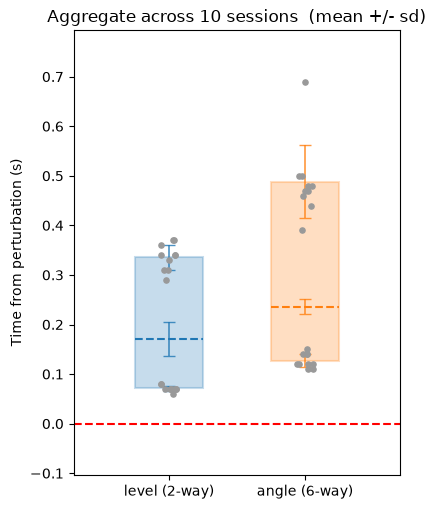

In [63]:
# "Fake boxplot" AGGREGATE across sessions: same floating-bar summary as the
# single-session cell, but each edge is the across-session MEAN of the NO-INTERP
# landmark and the caps are +/-1 sd ACROSS SESSIONS (the meaningful spread).
# Grey dots = individual sessions. M063 excluded (same as the cell above).

RESULTS_DIR = Path("/mnt/datascience/workspaces/"
                   "mesparza-40inbrain-2dneuroelectronics-2ecom/"
                   "equake-interim-results/moving-window-response-timing")
EXCLUDE = ("M063",)

_paths = [p for p in sorted(RESULTS_DIR.glob("*.npz"))
          if not any(x in p.name for x in EXCLUDE)]
assert _paths, f"no per-session npz in {RESULTS_DIR} -- run the across-session cell first"

_lvl, _ang = [], []
for p in _paths:
    r = np.load(p, allow_pickle=True)
    mnames = list(r["metric_names"])
    _lvl.append(r["grid_level_avg"])
    _ang.append(r["grid_angle_avg"])
_lvl, _ang = np.array(_lvl), np.array(_ang)          # (n_sessions, 5)
n_sess = len(_paths)
ri, pi, fi = (mnames.index(k) for k in ("t_rise50", "t_peak", "t_fall50"))

bars = [("level (2-way)", _lvl, "tab:blue"),
        ("angle (6-way)", _ang, "tab:orange")]

fig, ax = plt.subplots(figsize=(4.2, 5.2))
W = 0.5
_rng = np.random.default_rng(0)
for x, (name, V, col) in enumerate(bars):
    lo, pk, hi = (np.nanmean(V[:, i]) for i in (ri, pi, fi))
    slo, spk, shi = (np.nanstd(V[:, i]) for i in (ri, pi, fi))
    ax.add_patch(plt.Rectangle((x - W / 2, lo), W, hi - lo,
                               facecolor=col, alpha=0.25, edgecolor=col, lw=1.5))
    ax.hlines(pk, x - W / 2, x + W / 2, color=col, ls="--", lw=1.5)          # mean t_peak
    for edge, sd in [(lo, slo), (pk, spk), (hi, shi)]:                       # +/-1 sd across sessions
        ax.errorbar(x, edge, yerr=sd, color=col, lw=1.2, capsize=4, alpha=0.8)
    for i in (ri, fi):                                                      # individual sessions
        ax.scatter(x + _rng.uniform(-0.06, 0.06, n_sess), V[:, i], s=14, c="0.6", zorder=3)
    # ax.text(x, hi, f"  t_fall50 {hi:.2f}", va="bottom", ha="center", fontsize=8)
    # ax.text(x, lo, f"  t_rise50 {lo:.2f}", va="top", ha="center", fontsize=8)
    # ax.text(x + W / 2 + 0.05, pk, f"t_peak {pk:.2f}", va="center", ha="left",
    #         fontsize=8, color=col)
    # ax.text(x, (lo + hi) / 2, f"FWHM\n{hi - lo:.2f} s", va="center", ha="center",
    #         fontsize=9, weight="bold")

ax.axhline(0, c="r", ls="--")                                               # onset
ax.set_xticks([0, 1])
ax.set_xticklabels([b[0] for b in bars])
ax.set_xlim(-0.7, 1.7)
ax.margins(y=0.15)
ax.set_ylabel("Time from perturbation (s)")
ax.set_title(f"Aggregate across {n_sess} sessions  (mean +/- sd)")
fig.tight_layout()
plt.show()


In [65]:
# Stats on the per-session NO-INTERP landmark deltas (angle - level).
#   delta_df : raw per-session delta for every metric (+ animal id)
#   tab1     : across sessions, ANIMAL-AGNOSTIC (sessions treated as independent)
#   tab2     : ANIMAL-AWARE -- collapse to one delta per animal, then test
#   (+ optional random-intercept LMM if statsmodels is importable)
# delta > 0 means the angle landmark is LATER / the interval WIDER than level.

import pandas as pd
from scipy import stats as _st

RESULTS_DIR = Path("/mnt/datascience/workspaces/"
                   "mesparza-40inbrain-2dneuroelectronics-2ecom/"
                   "equake-interim-results/moving-window-response-timing")
EXCLUDE = ("M063",)

_paths = [p for p in sorted(RESULTS_DIR.glob("*.npz"))
          if not any(x in p.name for x in EXCLUDE)]
assert _paths, f"no per-session npz in {RESULTS_DIR} -- run the across-session cell first"

_rows = []
for p in _paths:
    r = np.load(p, allow_pickle=True)
    mnames = list(r["metric_names"])
    sess = str(r["session"])
    _rows.append(dict(session=sess, animal=sess.split("_")[0],
                      **dict(zip(mnames, r["grid_delta_avg"]))))
delta_df = pd.DataFrame(_rows).set_index("session")
METR = mnames
print(f"{len(delta_df)} sessions, {delta_df['animal'].nunique()} animals "
      f"(excluded {EXCLUDE})")
display(delta_df.round(3))


def _one_sample_stats(x):
    """One-sample summary + tests of `x` against 0 (paired level-vs-angle)."""
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]
    n = x.size
    n_pos, n_neg = int((x > 0).sum()), int((x < 0).sum())
    out = dict(n=n, mean=np.mean(x), median=np.median(x),
               sd=np.std(x, ddof=1) if n > 1 else np.nan,
               min=np.min(x), max=np.max(x), n_pos=n_pos, n_neg=n_neg)
    try:
        out["wilcoxon_p"] = _st.wilcoxon(x).pvalue           # signed-rank vs 0
    except ValueError:
        out["wilcoxon_p"] = np.nan
    out["sign_p"] = _st.binomtest(n_pos, n_pos + n_neg, 0.5).pvalue if (n_pos + n_neg) else np.nan
    out["t_p"] = _st.ttest_1samp(x, 0.0).pvalue if n > 1 else np.nan
    return out


# --- Table 1: animal-agnostic (n = sessions) --------------------------
tab1 = pd.DataFrame({m: _one_sample_stats(delta_df[m]) for m in METR}).T
print("\n=== across sessions, agnostic of animal ===")
display(tab1.round(4))

# --- Table 2: animal-aware (collapse to per-animal mean delta) --------
per_animal = delta_df.groupby("animal")[METR].mean()
print(f"\n=== per-animal deltas (n = {len(per_animal)} animals) ===")
display(per_animal.round(3))
tab2 = pd.DataFrame({m: _one_sample_stats(per_animal[m]) for m in METR}).T
print("=== across animals (session repeats averaged within animal) ===")
display(tab2.round(4))

# --- Optional: random-intercept LMM  delta ~ 1 + (1 | animal) ---------
try:
    import statsmodels.formula.api as smf
    _long = (delta_df.reset_index()
             .melt(id_vars=["session", "animal"], value_vars=METR,
                   var_name="metric", value_name="delta"))
    _lmm = {}
    for m in METR:
        sub = _long[_long["metric"] == m].dropna()
        fit = smf.mixedlm("delta ~ 1", sub, groups=sub["animal"]).fit(method="lbfgs")
        _lmm[m] = dict(intercept=fit.params["Intercept"], se=fit.bse["Intercept"],
                       z=fit.tvalues["Intercept"], p=fit.pvalues["Intercept"],
                       animal_var=float(fit.cov_re.iloc[0, 0]))
    print("\n=== random-intercept LMM: delta ~ 1 + (1 | animal) ===")
    display(pd.DataFrame(_lmm).T.round(4))
except ImportError:
    print("\n(statsmodels not installed -> skipping random-intercept LMM; "
          "`uv add statsmodels` to enable)")


10 sessions, 6 animals (excluded ('M063',))


,animal,t_rise50,t_peak,t_fall50,fwhm,centroid
session,,,,,,
M061_2025_03_04_10_00,M061,0.05,0.09,0.10,0.05,-0.095
M061_2025_03_05_14_00,M061,0.05,0.06,0.12,0.07,0.096
M061_2025_03_06_14_00,M061,0.04,0.01,0.16,0.12,0.022
M062_2025_03_20_14_00,M062,0.07,0.07,0.12,0.05,0.192
M062_2025_03_21_14_00,M062,0.07,0.05,0.10,0.03,-0.053
M078_2025_08_06_15_00,M078,0.07,0.10,0.08,0.01,-0.045
M086_2025_12_10_15_00,M086,0.04,0.09,0.35,0.31,0.049
M103_2026_02_18_15_30,M103,0.06,0.06,0.11,0.05,0.084
M103_2026_02_19_15_30,M103,0.04,0.02,0.19,0.15,0.028



=== across sessions, agnostic of animal ===


,n,mean,median,sd,min,max,n_pos,n_neg,wilcoxon_p,sign_p,t_p
t_rise50,10.0,0.0560,0.0550,0.0135,0.0400,0.0700,10.0,0.0,0.002,0.0020,0.0000
t_peak,10.0,0.0650,0.0650,0.0317,0.0100,0.1000,10.0,0.0,0.002,0.0020,0.0001
t_fall50,10.0,0.1520,0.1200,0.0793,0.0800,0.3500,10.0,0.0,0.002,0.0020,0.0002
fwhm,10.0,0.0960,0.0600,0.0873,0.0100,0.3100,10.0,0.0,0.002,0.0020,0.0070
centroid,10.0,0.0295,0.0254,0.0830,-0.0948,0.1918,7.0,3.0,0.375,0.3438,0.2899



=== per-animal deltas (n = 6 animals) ===


,t_rise50,t_peak,t_fall50,fwhm,centroid
animal,,,,,
M061,0.047,0.053,0.127,0.08,0.008
M062,0.070,0.060,0.110,0.04,0.070
M078,0.070,0.100,0.080,0.01,-0.045
M086,0.040,0.090,0.350,0.31,0.049
M103,0.050,0.040,0.150,0.10,0.056
M106,0.070,0.100,0.190,0.12,0.016


=== across animals (session repeats averaged within animal) ===


,n,mean,median,sd,min,max,n_pos,n_neg,wilcoxon_p,sign_p,t_p
t_rise50,6.0,0.0578,0.0600,0.0138,0.0400,0.0700,6.0,0.0,0.0312,0.0312,0.0001
t_peak,6.0,0.0739,0.0750,0.0260,0.0400,0.1000,6.0,0.0,0.0312,0.0312,0.0009
t_fall50,6.0,0.1678,0.1383,0.0967,0.0800,0.3500,6.0,0.0,0.0312,0.0312,0.0081
fwhm,6.0,0.1100,0.0900,0.1058,0.0100,0.3100,6.0,0.0,0.0312,0.0312,0.0515
centroid,6.0,0.0257,0.0326,0.0419,-0.0447,0.0696,5.0,1.0,0.1562,0.2188,0.1937


/tmp/ipykernel_958267/2295184881.py:74: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  fit = smf.mixedlm("delta ~ 1", sub, groups=sub["animal"]).fit(method="lbfgs")
/root/repos/earthquake-analysis/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:589: SingularMatrixWarning: Random effects covariance is singular
  return -self.score(params, *args) / nobs


LinAlgError: Singular matrix

## Tests with dpca examples

In [128]:
# number of neurons, time-points and stimuli
N,T,S = 100,250,6

# noise-level and number of trials in each condition
noise, n_samples = 0.2, 10

# build two latent factors
zt = (np.arange(T)/float(T))
zs = (np.arange(S)/float(S))

# build trial-by trial data
trialR = noise*np.random.randn(n_samples,N,S,T)
trialR += np.random.randn(N)[None,:,None,None]*zt[None,None,None,:]
trialR += np.random.randn(N)[None,:,None,None]*zs[None,None,:,None]

# trial-average data
R = np.mean(trialR,0)

# center data
R -= np.mean(R.reshape((N,-1)),1)[:,None,None]

In [129]:
trialR.shape

(10, 100, 6, 250)

In [130]:
R.shape

(100, 6, 250)

In [131]:
dpca = dPCA.dPCA(labels='st',regularizer=1e-3)
dpca.protect = ['t']

In [132]:
Z = dpca.fit_transform(R,trialR)

In [133]:
Z.keys()

dict_keys(['s', 't', 'st'])

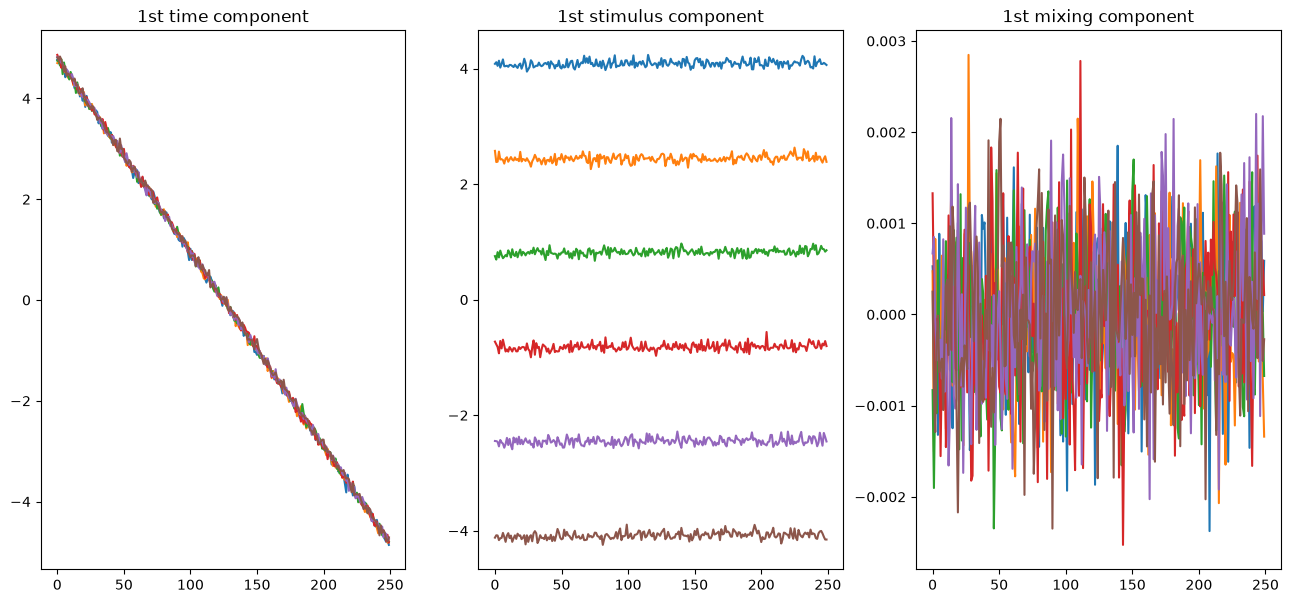

In [135]:
time = np.arange(T)

plt.figure(figsize=(16,7))
plt.subplot(131)

for s in range(S):
    plt.plot(time,Z['t'][0,s])

plt.title('1st time component')
    
plt.subplot(132)

for s in range(S):
    plt.plot(time,Z['s'][0,s])
    
plt.title('1st stimulus component')
    
plt.subplot(133)

for s in range(S):
    plt.plot(time,Z['st'][0,s])
    
plt.title('1st mixing component')
plt.show()

In [ ]:
significance_masks = dpca.significance_analysis(R,  trialR, n_shuffles=10, n_splits=10, n_consecutive=10)

## Apply dpca

In [111]:
# trials = X_kept.reshape()
labels = d['ep_code'][keep]
classes, counts = np.unique(labels, return_counts=True)
n_classes, min_n = len(classes), int(counts.min())
print(n_classes, min_n)

12 9


In [112]:
rng = np.random.default_rng(seed=0)  # reproducible

keep_idx = []
for c in classes:
    idx_c = np.where(labels == c)[0]
    chosen = rng.choice(idx_c, size=min_n, replace=False)
    keep_idx.append(chosen)

keep_idx = np.concatenate(keep_idx)
rng.shuffle(keep_idx)  # optional, so classes aren't blocked together

X_b = X_kept[keep_idx]
labels_b = labels[keep_idx]


In [113]:
level = np.array([Params.sol_dir_to_level[s] for s in labels_b])
trial_angles = np.array([Params.sol_dir_to_angle[s] for s in labels_b])


cond_labels = list(zip(level, trial_angles))
unique_conds = sorted(set(cond_labels))
n_conditions = len(unique_conds)

cond_to_idx = {c: np.where([cl == c for cl in cond_labels])[0]
               for c in unique_conds}
counts = {c: len(idx) for c, idx in cond_to_idx.items()}
print(counts)          # check balance across the 12 combos
min_n = min(counts.values())

{(np.int64(0), np.int64(30)): 9, (np.int64(0), np.int64(90)): 9, (np.int64(0), np.int64(150)): 9, (np.int64(0), np.int64(210)): 9, (np.int64(0), np.int64(270)): 9, (np.int64(0), np.int64(330)): 9, (np.int64(1), np.int64(30)): 9, (np.int64(1), np.int64(90)): 9, (np.int64(1), np.int64(150)): 9, (np.int64(1), np.int64(210)): 9, (np.int64(1), np.int64(270)): 9, (np.int64(1), np.int64(330)): 9}


In [114]:
X_tf = X_b.transpose(0, 2, 1)          # (108, 57, 401) trials, features, time

levels = sorted(set(level))            # cond_level values
angles = sorted(set(trial_angles))     # cond_angle values

rng = np.random.default_rng(0)
level_blocks = []
for lv in levels:
    angle_blocks = []
    for ang in angles:
        idx = cond_to_idx[(lv, ang)]
        if len(idx) > min_n:           # subsample down if unbalanced
            idx = rng.choice(idx, size=min_n, replace=False)
        angle_blocks.append(X_tf[idx])                  # (min_n, 57, 401)
    level_blocks.append(np.stack(angle_blocks, axis=2))  # (min_n, 57, n_angles, 401)

trialX = np.stack(level_blocks, axis=2)  # (min_n, 57, n_levels, n_angles, 401)
trialX = trialX[:, :, :, :, resp_sl]
K, N, L, A, T = trialX.shape

X = trialX.mean(0)
X -= np.mean(X.reshape((N,-1)),1)[:,None,None, None]


In [115]:
X.shape

(57, 2, 6, 300)

In [117]:
dpca = dPCA.dPCA(
    labels='lat',
    regularizer=0.001,
    join= {'lt': ['l','lt'], 'at': ['a', 'at'], 'lat':['la', 'lat']}
)
dpca.protect = ['t']
Z = dpca.fit_transform(X,trialX)

## Explained variances

In [ ]:
def get_var_split(dpca_obj, X):
    # Stack encoders and decoders
    keys = list(dpca_obj.marginalizations.keys())
    D = np.hstack([dpca_obj.D[k] for k in keys])
    F = np.hstack([dpca_obj.P[k] for k in keys])
    whichMarg = np.concatenate([[k]*dpca_obj.D[k].shape[1] for k in keys])

    # Marginalize
    Xmargs = dpca_obj._marginalize(X.copy())
    Xflat  = X.reshape(X.shape[0], -1)
    totalVar = np.sum(Xflat.reshape(X.shape[0], -1)**2)

    # The concat transformed object
    comps = D.shape[-1]
    Z = D.T @ Xflat

    # Get explained variance
    componentVar = np.array([1 - np.sum((Xflat - np.outer(F[:,i], Z[i,:]))**2)/totalVar for i in range(comps)]) * 100

    margVar = np.zeros((len(keys), comps))
    for comp in range(comps):
        for k_, k in enumerate(keys):
            recon = np.outer(F[:,comp], D[:,comp] @ Xmargs[k])
            margVar[k_,comp] = (np.sum(Xmargs[k]**2) - np.sum((Xmargs[k]-recon)**2)) / totalVar * 100

    order = np.argsort(-componentVar)
    # `order` (variance ranking, best first) is returned too so other plots can reorder
    # the encoder/decoder axes the same way the bars are ordered.
    return componentVar[order], margVar[:,order], whichMarg[order], order

def plot_var_split(componentVar, margVar, whichMarg, keys, colours=None, names=None, n_show=15):
    """Stacked bar plot of dPCA explained variance (eLife 2016, Fig. 3-6 style).

    Components 1..n_show are labelled with the marginalization they were extracted
    for (`whichMarg`): the x-tick number is tinted in that marginalization's colour
    and its short key is written above the bar.
    """
    n_show = min(n_show, len(componentVar))
    x = np.arange(1, n_show + 1)
    colours = colours or plt.get_cmap("tab10").colors
    names = names or keys
    cmap = dict(zip(keys, colours))

    fig, ax = plt.subplots(figsize=(0.4 * n_show + 1.5, 3))
    bottom = np.zeros(n_show)
    for i, k in enumerate(keys):
        ax.bar(x, margVar[i, :n_show], bottom=bottom, width=0.75,
               color=colours[i], label=names[i])
        bottom += margVar[i, :n_show]

    # per-component marginalization label (the dominant marg the component belongs to)
    marg_show = np.asarray(whichMarg)[:n_show]
    pad = 0.02 * bottom.max()
    # for xi, top, m in zip(x, bottom, marg_show):
    #     ax.text(xi, top + pad, str(m), rotation=90, ha="center", va="bottom",
    #             fontsize=8, color=cmap.get(m, "k"))

    ax.set_xticks(x)
    ax.set_xticklabels(x)
    for tl, m in zip(ax.get_xticklabels(), marg_show):
        tl.set_color(cmap.get(m, "k"))

    ax.set_xlim(0.5, n_show + 0.5)
    ax.set_ylim(0, bottom.max() * 1.18)
    ax.set_xlabel("Component")
    ax.set_ylabel("Component variance (%)")
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(frameon=False)
    return ax

def plot_var_pie(margVar, keys, colours=None, names=None, ax=None,
                 dpca_obj=None, X=None, trialX=None):
    """Pie of dPCA marginalized variance.

    Default (eLife 2016 Figs 3-6, panel c-style): each slice is the variance one
    marginalization explains summed over ALL its components, slice_j =
    sum_k margVar[j, k], as a % of TOTAL PSTH variance -- slices sum to the
    fraction dPCA explains, not to 100.

    If `dpca_obj`, `X` and `trialX` are all passed: panel d -- each slice is
    that marginalization's SIGNAL variance (its full marginalized variance
    minus its degrees-of-freedom share of the finite-trial noise), as a % of
    total signal variance; slices sum to ~100.
    """
    if dpca_obj is not None and X is not None and trialX is not None:
        keys, slices = dim.noise_corrected_marg_var(dpca_obj, X, trialX)
        slices = np.asarray(slices) * 100
        title = "Marginalized signal variance\n(noise-corrected, Kobak 2016 Fig 3-6d)"
    else:
        slices = np.asarray(margVar).sum(axis=1)
        title = f"Marginalized variance\n(dPCA explains {slices.sum():.1f}% of total)"

    colours = list(colours or plt.get_cmap("tab10").colors)
    names = names or list(keys)
    if ax is None:
        fig, ax = plt.subplots(figsize=(3.6, 3.6))
    ax.pie(
        slices,
        colors=colours[:len(slices)],
        labels=[f"{n}\n{s:.1f}%" for n, s in zip(names, slices)],
        startangle=90,
        counterclock=False,
        wedgeprops=dict(edgecolor="w", linewidth=1),
    )
    ax.set_title(title)
    return ax

def signal_variance_fraction(X, trialX, time_axis=-1):
    """
    Fraction of X's total variance that is real signal, vs. residual noise
    from averaging a finite number of trials (Kobak et al. 2016, dashed
    line in Figs 3-6c).
    """
    Xflat = X.reshape(X.shape[0], -1)
    totalVar = np.sum(Xflat ** 2)

    Cnn = rebalanced_noise_variance(trialX, time_axis=time_axis)
    K = np.sum(~np.isnan(trialX), axis=0).astype(float)
    t_ax = time_axis if time_axis >= 0 else X.ndim + time_axis
    Kbar = np.take(K, 0, axis=t_ax).reshape(X.shape[0], -1).mean(axis=1)

    Q = np.sum(Cnn / Kbar)  # SQT is already baked into Cnn -- no extra factor
    return float(1 - Q / totalVar)


def plot_cumulative_variance(dpca_obj, X, trialX=None, n_show=15, time_axis=-1, ax=None):
    """Cumulative variance explained by dPCA (red) vs. PCA (black), with the
    signal-variance ceiling as a dashed line -- Kobak et al. 2016, Figs 3-6c."""
    keys = list(dpca_obj.marginalizations.keys())
    F = np.hstack([dpca_obj.P[k] for k in keys])
    D = np.hstack([dpca_obj.D[k] for k in keys])
    Xflat = X.reshape(X.shape[0], -1)
    totalVar = np.sum(Xflat ** 2)

    Z = D.T @ Xflat
    compVar = np.array([1 - np.sum((Xflat - np.outer(F[:, i], Z[i])) ** 2) / totalVar
                         for i in range(F.shape[1])])
    order = np.argsort(-compVar)[:min(n_show, F.shape[1])]
    Fo, Do = F[:, order], D[:, order]

    dpca_cum = np.array([(1 - np.sum((Xflat - Fo[:, :q] @ (Do[:, :q].T @ Xflat)) ** 2) / totalVar) * 100
                          for q in range(1, len(order) + 1)])

    Xc = Xflat - Xflat.mean(axis=1, keepdims=True)
    s = np.linalg.svd(Xc, full_matrices=False, compute_uv=False)
    pca_cum = np.cumsum(s[:len(order)] ** 2) / np.sum(Xc ** 2) * 100

    if ax is None:
        _, ax = plt.subplots(figsize=(0.42 * len(order) + 1.5, 3))
    x = np.arange(1, len(order) + 1)
    ax.plot(x, pca_cum, "-o", color="black", ms=3, label="PCA")
    ax.plot(x, dpca_cum, "-o", color="crimson", ms=3, label="dPCA")
    if trialX is not None:
        sig = signal_variance_fraction(X, trialX, time_axis=time_axis) * 100
        print(sig)
        ax.axhline(sig, ls="--", color="gray", lw=1, label=f"signal variance ({sig:.1f}%)")
    ax.set_ylim(0, 100)
    ax.set_xlabel("Component")
    ax.set_ylabel("Cumulative variance explained (%)")
    ax.legend(frameon=False, loc="lower right", fontsize=8)
    return ax

/tmp/ipykernel_656353/4249484071.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[0].legend()


Text(0.5, 0, 'Time (s)')

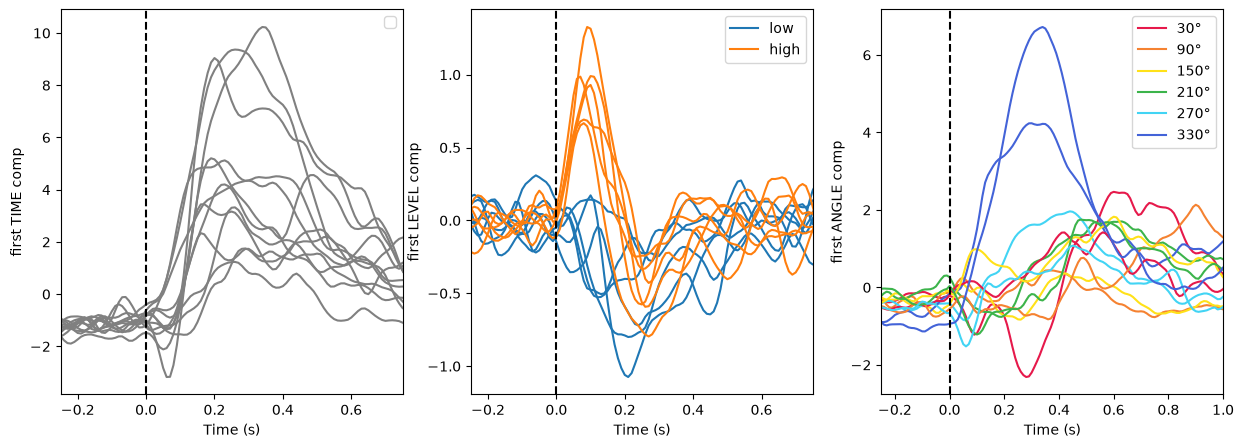

In [83]:
time = np.arange(RESPONSE[0], RESPONSE[1], step=0.01)
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

for l in range(L):
    for a in range(A):
        axs[0].plot(time, Z['t'][0,l,a,:], color='grey')
axs[0].axvline(0, color='k', ls='dashed')
axs[0].set_xlim([-0.25, 0.75])
axs[0].legend()
axs[0].set_ylabel('first TIME comp')
axs[0].set_xlabel('Time (s)')


for l, color, level in zip(range(L), ['tab:blue', 'tab:orange'], ('low', 'high')):
    for a in range(A):
        axs[1].plot(time, Z['lt'][0,l,a,:], color=color, label=level if a == 0 else None)
axs[1].axvline(0, color='k', ls='dashed')
axs[1].set_xlim([-0.25, 0.75])
axs[1].legend()
axs[1].set_ylabel('first LEVEL comp')
axs[1].set_xlabel('Time (s)')

# discrete red -> orange -> yellow -> green -> cyan -> blue palette
colors_a = ['#e6194B', '#f58231', '#ffe119', '#3cb44b', '#42d4f4', '#4363d8']

for l in range(L):
    for a, color in zip(range(A), colors_a):
        axs[2].plot(time, Z['at'][0, l, a, :], color=color, label=f'{angles[a]}°' if l == 0 else None)
axs[2].set_xlim([-0.25, 1])
axs[2].legend()
axs[2].axvline(0, color='k', ls='dashed')
axs[2].set_ylabel('first ANGLE comp')
axs[2].set_xlabel('Time (s)')



In [144]:
whichMarg[:15]

array(['t', 'at', 'at', 'lat', 'lat', 'lt', 't', 't', 'at', 'at', 'lat',
       'lt', 'lat', 'lt', 'at'], dtype='<U3')

<Axes: title={'center': 'Marginalized variance\n(dPCA explains 74.7% of total)'}>

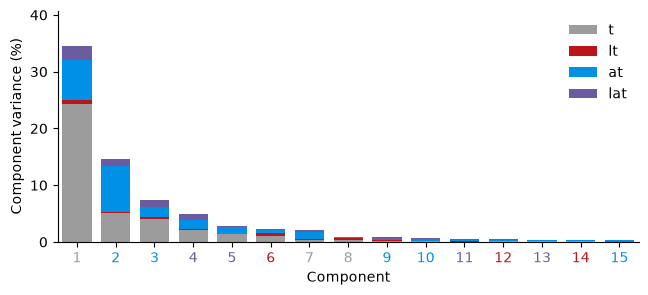

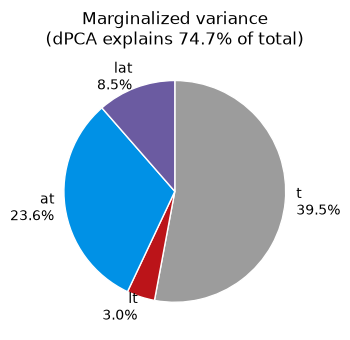

In [165]:
componentVar, margVar, whichMarg, order = get_var_split(dpca, X)
keys = list(dpca.marginalizations.keys())
colors = ["#9C9C9C", "#BB1419", "#0091E6", "#6B5BA1"]

plot_var_split(componentVar, margVar, whichMarg, keys,
               colours=colors)  # blue/red/gray/purple, paper's palette
            #    names=["Stimulus", "Decision", "Condition-independent", "Interaction"])

plot_var_pie(margVar, keys, colours=colors)

In [ ]:
plot_var_pie(margVar, keys,
             colours=["#9C9C9C", "#BB1419", "#0091E6", "#6B5BA1"])  # same palette as the bar plot

## Rebalancing

In [191]:
X_b = X_kept
labels_b = labels

level = np.array([Params.sol_dir_to_level[s] for s in labels_b])
trial_angles = np.array([Params.sol_dir_to_angle[s] for s in labels_b])

cond_labels = list(zip(level, trial_angles))
unique_conds = sorted(set(cond_labels))
n_conditions = len(unique_conds)

cond_to_idx = {c: np.where([cl == c for cl in cond_labels])[0]
               for c in unique_conds}
counts = {c: len(idx) for c, idx in cond_to_idx.items()}

X_tf = X_b.transpose(0, 2, 1)          # (trials, features, time)
X_tf = X_tf[:, :, resp_sl]             # response-window slice, applied up front now

levels = sorted(set(level))            # cond_level values
angles = sorted(set(trial_angles))     # cond_angle values
L, A = len(levels), len(angles)
N, T = X_tf.shape[1], X_tf.shape[2]
K = max(counts.values())               # NOT a fixed min_n anymore -- just the largest condition

# NaN-padded single-trial array: each condition keeps ALL its trials, padded
# with NaN past its own count up to K. This is the standard trialX
# convention rebalanced_noise_variance / fit_dpca_rebalanced expect.
trialX = np.full((K, N, L, A, T), np.nan)
for li, lv in enumerate(levels):
    for ai, ang in enumerate(angles):
        idx = cond_to_idx[(lv, ang)]
        trialX[:len(idx), :, li, ai, :] = X_tf[idx]

X = np.nanmean(trialX, axis=0)                            # nanmean, not mean -- trials are now padded
X -= np.mean(X.reshape((N, -1)), 1)[:, None, None, None]  # centering unchanged

In [192]:
import numpy as np
from sklearn.utils.extmath import randomized_svd


def rebalanced_noise_variance(trialX, time_axis=-1):
    """
    Per-neuron noise variance, re-balanced across conditions (each condition
    weighted equally, regardless of trial count). Sums over time first, then
    sums (not averages) over the remaining conditions -- this is exactly
    dpca_getNoiseCovariance.m's 'averaged' branch, i.e. SQT * Cnoise_tilde
    from the paper (the SQT and the paper's 1/SQT cancel algebraically, so
    what MATLAB actually computes and uses is this unscaled sum).
    """
    X = np.nanmean(trialX, axis=0)                       # PSTH
    K = np.sum(~np.isnan(trialX), axis=0).astype(float)   # trials per neuron/condition/time
    K[K == 0] = np.nan
    SS = np.nansum((trialX - X[None, ...]) ** 2, axis=0)  # summed sq. deviations per cell

    t_ax = time_axis if time_axis >= 0 else X.ndim + time_axis
    SS_sumT = np.sum(SS, axis=t_ax).reshape(X.shape[0], -1)         # sum over time first
    K_noT = np.take(K, 0, axis=t_ax).reshape(X.shape[0], -1)        # trial count doesn't vary with time

    with np.errstate(invalid="ignore"):
        return np.nansum(SS_sumT / K_noT, axis=1)                  # sum, not mean, over conditions


def fit_dpca_rebalanced(dpca_obj, X, trialX, lam=None):
    """
    Refit dpca_obj.D / dpca_obj.P using the re-balanced ridge penalty
    Omega = diag(noise_var) + lambda^2*I in place of the plain lambda^2*I
    dPCA.py uses internally -- matches dpca.m's actual closed-form solve.
    Verified against the real dpca.m + dpca_getNoiseCovariance.m in Octave:
    axis directions, leakage, and the noise estimate all match exactly.
    """
    n = X.shape[0]
    Xcen = dpca_obj._zero_mean(X)
    rX = Xcen.reshape(n, -1)

    lam = dpca_obj.regularizer if lam is None else lam
    lam2 = (lam * np.sum(rX ** 2)) ** 2 if lam else 0.0     # matches dPCA._fit's own convention
    Omega = np.diag(rebalanced_noise_variance(trialX)) + lam2 * np.eye(n)

    P, D = {}, {}
    for key, mX in dpca_obj._marginalize(Xcen).items():
        mX = mX.reshape(n, -1)
        C = mX @ rX.T @ np.linalg.inv(rX @ rX.T + Omega)    # A_RR = X_j X^T (XX^T + Omega)^-1
        nc = dpca_obj.n_components[key] if isinstance(dpca_obj.n_components, dict) else dpca_obj.n_components
        U, _, _ = randomized_svd(C @ rX, n_components=nc, n_iter=dpca_obj.n_iter,
                                  random_state=np.random.randint(10e5))
        P[key], D[key] = U, (U.T @ C).T

    dpca_obj.P, dpca_obj.D = P, D
    return dpca_obj

In [193]:
# dpca = dPCA(labels='sdt', n_components=10, regularizer=1e-3)
dpca = dPCA.dPCA(
    labels='lat',
    regularizer=0.0012,
    join= {'lt': ['l','lt'], 'at': ['a', 'at'], 'lat':['la', 'lat']}
)
dpca.protect = ['t']
dpca.fit(X, trialX)
fit_dpca_rebalanced(dpca, X, trialX)   # overwrites dpca.D / dpca.P in place
Z = dpca.transform(X)

/tmp/ipykernel_656353/4249484071.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[0].legend()


Text(0.5, 0, 'Time (s)')

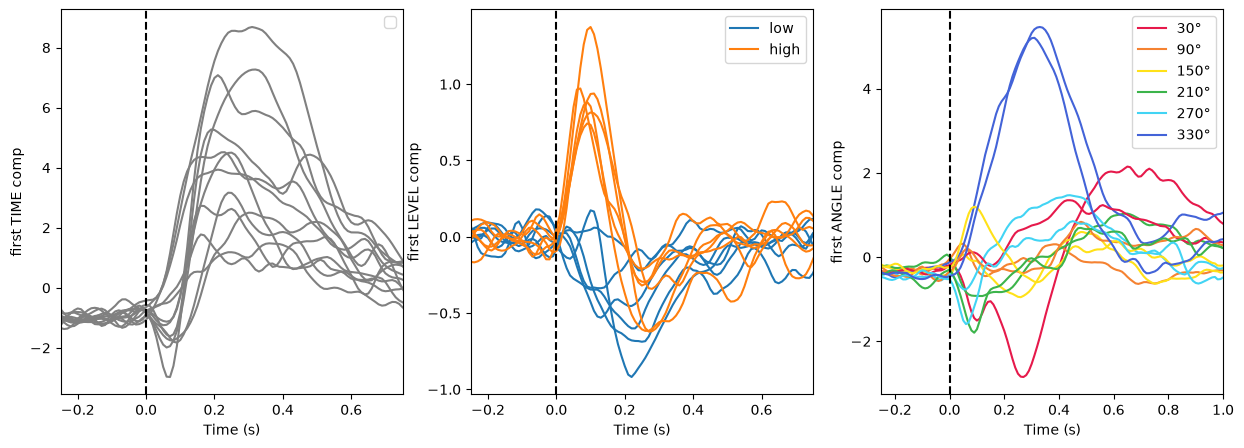

In [194]:
time = np.arange(RESPONSE[0], RESPONSE[1], step=0.01)
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

for l in range(L):
    for a in range(A):
        axs[0].plot(time, Z['t'][0,l,a,:], color='grey')
axs[0].axvline(0, color='k', ls='dashed')
axs[0].set_xlim([-0.25, 0.75])
axs[0].legend()
axs[0].set_ylabel('first TIME comp')
axs[0].set_xlabel('Time (s)')


for l, color, level in zip(range(L), ['tab:blue', 'tab:orange'], ('low', 'high')):
    for a in range(A):
        axs[1].plot(time, Z['lt'][0,l,a,:], color=color, label=level if a == 0 else None)
axs[1].axvline(0, color='k', ls='dashed')
axs[1].set_xlim([-0.25, 0.75])
axs[1].legend()
axs[1].set_ylabel('first LEVEL comp')
axs[1].set_xlabel('Time (s)')

# discrete red -> orange -> yellow -> green -> cyan -> blue palette
colors_a = ['#e6194B', '#f58231', '#ffe119', '#3cb44b', '#42d4f4', '#4363d8']

for l in range(L):
    for a, color in zip(range(A), colors_a):
        axs[2].plot(time, Z['at'][0, l, a, :], color=color, label=f'{angles[a]}°' if l == 0 else None)
axs[2].set_xlim([-0.25, 1])
axs[2].legend()
axs[2].axvline(0, color='k', ls='dashed')
axs[2].set_ylabel('first ANGLE comp')
axs[2].set_xlabel('Time (s)')



<Axes: xlabel='Component', ylabel='Component variance (%)'>

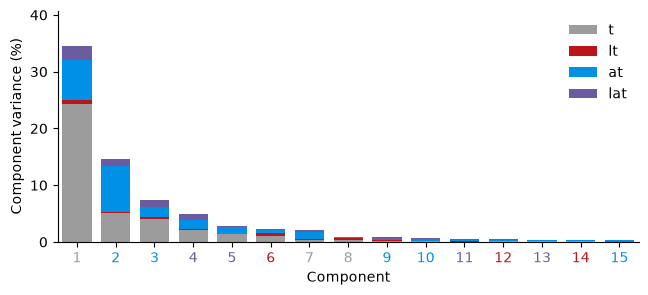

In [195]:
componentVar, margVar, whichMarg, order = get_var_split(dpca, X)
keys = list(dpca.marginalizations.keys())

plot_var_split(componentVar, margVar, whichMarg, keys,
               colours=["#9C9C9C", "#BB1419", "#0091E6", "#6B5BA1"])  # blue/red/gray/purple, paper's palette
            #    names=["Stimulus", "Decision", "Condition-independent", "Interaction"])

In [ ]:
plot_var_pie(margVar, keys, dpca_obj=dpca, X=X, trialX=trialX,
             colours=["#9C9C9C", "#BB1419", "#0091E6", "#6B5BA1"])  # same palette as the bar plot

74.73538889719636


<Axes: xlabel='Component', ylabel='Cumulative variance explained (%)'>

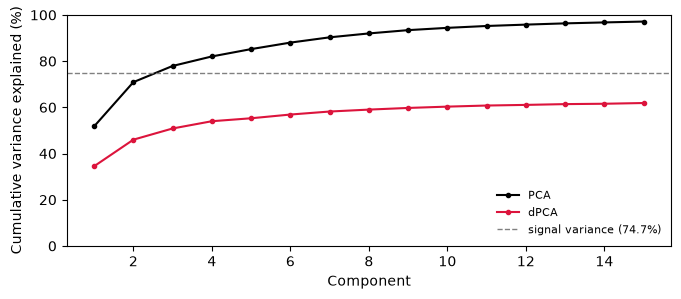

In [201]:
plot_cumulative_variance(dpca, X, trialX)

## Component orthogonality

<Axes: title={'center': 'lower: corr(Z)   |   upper: encoder $\\cdot$ encoder'}, xlabel='Component', ylabel='Component'>

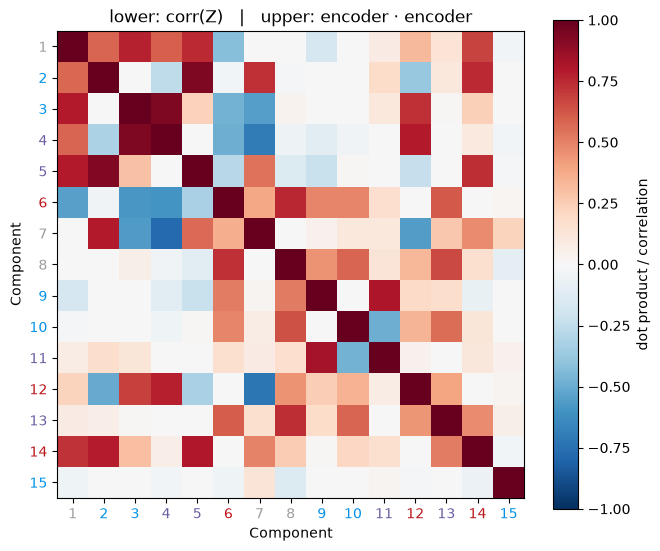

In [129]:
def plot_component_dotprod(dpca_obj, X, keys, colours=None, n_show=15):
    """Dot-product heatmap between dPCA components (eLife 2016, dpca_plot.m panel).

    Component ordering / marginalization labels come straight from `get_var_split`
    (same ranking as the explained-variance bars). Mimics the MATLAB `dpca_plot.m`
    "component orthogonality" subplot:
        a   = corr(Z(:,1:n))          -> lower triangle: correlation of the demixed time series
        b   = V(:,1:n)' * V(:,1:n)    -> upper triangle: dot products of the unit-norm ENCODER axes
        map = tril(a,-1) + triu(b)    -> one matrix, red<->blue, range [-1, 1]
    dPCA does not enforce orthogonality, so the off-diagonal terms show how demixed the axes are.
    """
    # Reuse the function already in the notebook for the variance ranking + marginalization tags.
    _, _, whichMarg, order = get_var_split(dpca_obj, X)

    n_show = min(n_show, len(order))
    order = order[:n_show]
    marg_show = whichMarg[:n_show]          # get_var_split already returns whichMarg in `order`

    D = np.hstack([dpca_obj.D[k] for k in keys])[:, order]            # decoders  (N x n_show)
    F = np.hstack([dpca_obj.P[k] for k in keys])[:, order]            # encoders  (N x n_show)
    Dn = D / np.linalg.norm(D, axis=0)                                # unit-norm, as in the package
    Fn = F / np.linalg.norm(F, axis=0)

    Xflat = X.reshape(X.shape[0], -1)
    Z = Dn.T @ Xflat                                                  # demixed time series
    corr = np.corrcoef(Z)                                             # lower triangle
    dot = Fn.T @ Fn                                                   # upper triangle
    tri = np.tril(np.ones_like(corr), -1).astype(bool)
    dmap = np.where(tri, corr, dot)

    colours = colours or plt.get_cmap("tab10").colors
    cmap = dict(zip(keys, colours))
    n = dmap.shape[0]

    fig, ax = plt.subplots(figsize=(0.35 * n + 1.5, 0.35 * n + 1.2))
    im = ax.imshow(dmap, cmap="RdBu_r", vmin=-1, vmax=1)
    ax.set_xticks(range(n)); ax.set_yticks(range(n))
    ax.set_xticklabels(range(1, n + 1)); ax.set_yticklabels(range(1, n + 1))
    for tl, m in zip(ax.get_xticklabels(), marg_show):
        tl.set_color(cmap[m])
    for tl, m in zip(ax.get_yticklabels(), marg_show):
        tl.set_color(cmap[m])
    ax.set_xlabel("Component")
    ax.set_ylabel("Component")
    ax.set_title(r"lower: corr(Z)   |   upper: encoder $\cdot$ encoder")
    fig.colorbar(im, ax=ax, shrink=0.8, label="dot product / correlation")
    fig.tight_layout()
    return ax


plot_component_dotprod(dpca, X, keys,
                       colours=["#9C9C9C", "#BB1419", "#0091E6", "#6B5BA1"])  # paper's palette


## Try with axis x direction x level

In [186]:
X_b = X_kept
labels_b = labels

level = np.array([Params.sol_dir_to_level[s] for s in labels_b])
trial_angles = np.array([Params.sol_dir_to_angle[s] for s in labels_b])

# Split each of the 6 angles into an AXIS (3 values: the 30/90/150 deg lines through the
# animal, independent of which end the perturbation came from) and a DIRECTION (2 values:
# which of the two opposite ends of that axis, e.g. 30 vs 210 deg). This works because the
# six sol_dir_to_angle values are exactly {30, 90, 150} and their +180 deg opposites
# {210, 270, 330}, so angle = axis + 180 * direction.
axis = trial_angles % 180
direction = (trial_angles // 180).astype(int)

cond_labels = list(zip(level, axis, direction))
unique_conds = sorted(set(cond_labels))
n_conditions = len(unique_conds)

cond_to_idx = {c: np.where([cl == c for cl in cond_labels])[0]
               for c in unique_conds}
counts = {c: len(idx) for c, idx in cond_to_idx.items()}

X_tf = X_b.transpose(0, 2, 1)          # (trials, features, time)
X_tf = X_tf[:, :, resp_sl]             # response-window slice, applied up front now

levels = sorted(set(level))            # cond_level values
axes_ = sorted(set(axis))              # cond_axis values (30, 90, 150 deg)
directions = sorted(set(direction))    # cond_direction values (0, 1)
L, A, D = len(levels), len(axes_), len(directions)
N, T = X_tf.shape[1], X_tf.shape[2]
K = max(counts.values())               # NOT a fixed min_n anymore -- just the largest condition

# NaN-padded single-trial array: each condition keeps ALL its trials, padded
# with NaN past its own count up to K. This is the standard trialX
# convention rebalanced_noise_variance / fit_dpca_rebalanced expect.
trialX = np.full((K, N, L, A, D, T), np.nan)
for li, lv in enumerate(levels):
    for ai, ax in enumerate(axes_):
        for di, dr in enumerate(directions):
            idx = cond_to_idx[(lv, ax, dr)]
            trialX[:len(idx), :, li, ai, di, :] = X_tf[idx]

X = np.nanmean(trialX, axis=0)                                   # nanmean, not mean -- trials are now padded
X -= np.mean(X.reshape((N, -1)), 1)[:, None, None, None, None]   # centering unchanged, one more axis to broadcast over

In [187]:
trialX.shape

(25, 57, 2, 3, 2, 300)

In [188]:
# dpca = dPCA(labels='sdt', n_components=10, regularizer=1e-3)
# labels: l=level, a=axis, d=direction, t=time. join collapses each "static"
# (no-time) marginalization into its time-varying counterpart, the same pattern
# as the l/a/t version above generalized to l/a/d/t -- e.g. the pure level effect
# 'l' (near-zero after centering) is folded into 'lt', 'la' into 'lat', etc.
# This keeps every returned marginalization time-resolved, ending in 't'.
dpca = dPCA.dPCA(
    labels='ladt',
    regularizer=0.0012,
    join={
        'lt': ['l', 'lt'], 'at': ['a', 'at'], 'dt': ['d', 'dt'],
        'lat': ['la', 'lat'], 'ldt': ['ld', 'ldt'], 'adt': ['ad', 'adt'],
        'ladt': ['lad', 'ladt'],
    }
)
dpca.protect = ['t']
dpca.fit(X, trialX)
fit_dpca_rebalanced(dpca, X, trialX)   # overwrites dpca.D / dpca.P in place
Z = dpca.transform(X)

<Axes: xlabel='Component', ylabel='Component variance (%)'>

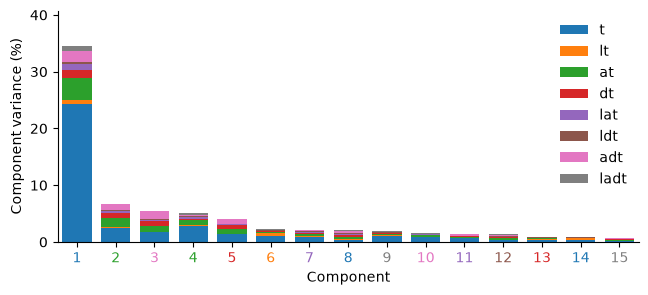

In [189]:
componentVar, margVar, whichMarg, order = get_var_split(dpca, X)
keys = list(dpca.marginalizations.keys())
colors=["#9C9C9C", "#BB1419", "#0081CC", "#079702", "#7F029E", "#019E91"]

plot_var_split(componentVar, margVar, whichMarg, keys)

In [ ]:
plot_var_pie(margVar, keys, dpca_obj=dpca, X=X, trialX=trialX,)  # same palette as the bar plot

## Noise floor (label-shuffle test)

`get_var_split`'s numbers above are in-sample: the encoder/decoder axes are *fit* to
maximize each marginalization's variance, so even a marginalization with zero true
effect will show a nonzero % just from fitting flexibility -- worse the fewer trials
per condition (K is as low as 9 for some cells here) and the more marginalizations
competing for the same neurons (8, once axis/direction/level and their interactions
are all separated out). This section builds an empirical noise floor: repeatedly
shuffle the `(level, axis, direction)` triplet across the trial pool (destroying every
condition effect -- main effects AND interactions -- while keeping each trial's actual
neural data and the exact per-condition trial counts `K` unchanged), refit the whole
pipeline, and see how much marginalized variance shows up in each category by chance
alone. Comparing the real value against that null answers the question that matters
most for the interaction terms (`lat`, `ldt`, `adt`, `ladt`): are they above what
unstructured trial noise alone produces at this N and this K, or are they
indistinguishable from it?

In [ ]:
def build_trialX_ladt(level, axis, direction, X_tf, N, T, levels, axes_, directions, L, A, D):
    """Same construction as the cell above, factored out so the shuffle loop below
    can call it with permuted labels without duplicating the nested loop."""
    cond_labels = list(zip(level, axis, direction))
    cond_to_idx = {c: np.where([cl == c for cl in cond_labels])[0] for c in set(cond_labels)}
    K = max(len(v) for v in cond_to_idx.values())
    trialX = np.full((K, N, L, A, D, T), np.nan)
    for li, lv in enumerate(levels):
        for ai, ax in enumerate(axes_):
            for di, dr in enumerate(directions):
                idx = cond_to_idx.get((lv, ax, dr))
                if idx is not None:
                    trialX[:len(idx), :, li, ai, di, :] = X_tf[idx]
    X = np.nanmean(trialX, axis=0)
    X -= np.mean(X.reshape((N, -1)), 1)[:, None, None, None, None]
    return X, trialX


def fit_ladt_dpca(X, trialX, dpca_kwargs):
    dpca_s = dPCA.dPCA(**dpca_kwargs)
    dpca_s.protect = ['t']
    dpca_s.fit(X, trialX)
    fit_dpca_rebalanced(dpca_s, X, trialX)
    return dpca_s


def noise_floor_null(level, axis, direction, X_tf, N, T, levels, axes_, directions, L, A, D,
                      dpca_kwargs, n_shuffles=200, seed=0):
    """Label-shuffle null for get_var_split's per-marginalization total variance
    (margVar.sum(axis=1), i.e. the pie-chart slices).

    Permutes the (level, axis, direction) triplet jointly across trials -- each
    trial keeps its own neural data but is randomly reassigned another trial's
    condition label. Because this is a permutation of the SAME multiset of labels,
    every condition still gets exactly the same number of trials K as in the real
    data (so the rebalanced ridge sees the same noise structure), but the labels
    are meaningless -- so ANY marginalized variance that shows up, including in
    the interaction terms, is by construction pure noise. Refit + rescored 200x
    by default; this is the single most expensive cell in the notebook (~<1 min
    for N=57, K<=25, 8 marginalizations -- each refit does one N x N matrix
    inverse for the rebalanced ridge plus 8 small SVDs).
    """
    rng = np.random.default_rng(seed)
    n_trials = X_tf.shape[0]
    keys_ref = None
    null = []
    for i in range(n_shuffles):
        perm = rng.permutation(n_trials)
        X_s, trialX_s = build_trialX_ladt(level[perm], axis[perm], direction[perm],
                                           X_tf, N, T, levels, axes_, directions, L, A, D)
        dpca_s = fit_ladt_dpca(X_s, trialX_s, dpca_kwargs)
        keys_s = list(dpca_s.marginalizations.keys())
        _, margVar_s, _, _ = get_var_split(dpca_s, X_s)
        null.append(margVar_s.sum(axis=1))   # sum over components is order-invariant
        if keys_ref is None:
            keys_ref = keys_s
    return keys_ref, np.array(null)


def plot_noise_floor(keys, observed, null, colours=None, ax=None):
    """Observed marginalized variance vs. its label-shuffle null (see noise_floor_null).

    Grey box = null distribution across shuffles (median, IQR, whiskers to
    1.5xIQR, outliers hidden); colored diamond = the real observed value; the
    number printed above each box is the empirical p-value -- the fraction of
    shuffles whose null value meets or exceeds the observed one. A marginalization
    whose diamond sits inside or just above its own box is not distinguishable
    from the noise floor at this N and K, regardless of how large its % looks on
    the pie chart.
    """
    colours = colours or plt.get_cmap("tab10").colors
    n = len(keys)
    if ax is None:
        fig, ax = plt.subplots(figsize=(0.9 * n + 1.5, 4))
    ax.boxplot([null[:, i] for i in range(n)], positions=np.arange(n), widths=0.5,
               showfliers=False, patch_artist=True,
               boxprops=dict(facecolor="0.85", edgecolor="0.4"),
               medianprops=dict(color="0.2"))
    for i, k in enumerate(keys):
        ax.scatter(i, observed[i], marker="D", s=60, color=colours[i], zorder=5,
                   edgecolor="k", linewidth=0.5)
        p = (null[:, i] >= observed[i]).mean()
        p_label = f"p={p:.3f}" if p > 0 else f"p<{1 / null.shape[0]:.3f}"
        ytop = max(observed[i], np.percentile(null[:, i], 99))
        ax.text(i, ytop + 0.03 * observed.max(), p_label,
                ha="center", va="bottom", fontsize=7, rotation=90)

    ax.set_xticks(np.arange(n))
    ax.set_xticklabels(keys)
    cmap = dict(zip(keys, colours))
    for tl, k in zip(ax.get_xticklabels(), keys):
        tl.set_color(cmap.get(k, "k"))
    ax.set_ylabel("Marginalized variance (% of total)")
    ax.set_title(f"Observed (diamond) vs. label-shuffle null (box, n={null.shape[0]} shuffles)")
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_ylim(0, observed.max() * 1.35)
    fig = ax.figure
    fig.tight_layout()
    return ax

In [ ]:
DPCA_KWARGS = dict(
    labels='ladt',
    regularizer=0.0012,
    join={
        'lt': ['l', 'lt'], 'at': ['a', 'at'], 'dt': ['d', 'dt'],
        'lat': ['la', 'lat'], 'ldt': ['ld', 'ldt'], 'adt': ['ad', 'adt'],
        'ladt': ['lad', 'ladt'],
    },
)

keys_null, null = noise_floor_null(level, axis, direction, X_tf, N, T, levels, axes_, directions, L, A, D,
                                    DPCA_KWARGS, n_shuffles=200, seed=0)
assert keys_null == keys, "marginalization order changed between the real fit and the null -- don't compare"

observed = margVar.sum(axis=1)   # same quantity as the pie chart slices, from the real (unshuffled) fit above
plot_noise_floor(keys, observed, null)

# Refactored dPCA

In [5]:
# Load the per-session decoding results saved by
# across-sessions/bhv-decode-solenoid/decode_solenoid_direction.py
FS = 100
BASE = (-1.6, -0.1)     # baseline window (s, rel. onset)
POST = (0.0, 1.0)       # response window
RESPONSE = (-1, 2)
N_SHUFFLE = 200
onset = 200
base_sl = slice(onset + int(BASE[0] * FS), onset + int(BASE[1] * FS))
post_sl = slice(onset + int(POST[0] * FS), onset + int(POST[1] * FS))
resp_sl = slice(onset + int(RESPONSE[0] * FS), onset + int(RESPONSE[1] * FS))



DATA_DIR = Path('/mnt/datascience/workspaces/mesparza-40inbrain-2dneuroelectronics-2ecom/equake-interim-results/cache')
npz_files = sorted(DATA_DIR.glob('*.npz'))
npz_files = [
    # PosixPath('/mnt/datascience/workspaces/mesparza-40inbrain-2dneuroelectronics-2ecom/equake-interim-results/cache/M061_2025_03_04_10_00.npz'),
    # PosixPath('/mnt/datascience/workspaces/mesparza-40inbrain-2dneuroelectronics-2ecom/equake-interim-results/cache/M061_2025_03_05_14_00.npz'),
    PosixPath('/mnt/datascience/workspaces/mesparza-40inbrain-2dneuroelectronics-2ecom/equake-interim-results/cache/M061_2025_03_06_14_00.npz'),
    # PosixPath('/mnt/datascience/workspaces/mesparza-40inbrain-2dneuroelectronics-2ecom/equake-interim-results/cache/M062_2025_03_20_14_00.npz'),
    # PosixPath('/mnt/datascience/workspaces/mesparza-40inbrain-2dneuroelectronics-2ecom/equake-interim-results/cache/M062_2025_03_21_14_00.npz'),
    # PosixPath('/mnt/datascience/workspaces/mesparza-40inbrain-2dneuroelectronics-2ecom/equake-interim-results/cache/M063_2025_03_13_14_00.npz'),
    # PosixPath('/mnt/datascience/workspaces/mesparza-40inbrain-2dneuroelectronics-2ecom/equake-interim-results/cache/M078_2025_08_06_15_00.npz'),
    # PosixPath('/mnt/datascience/workspaces/mesparza-40inbrain-2dneuroelectronics-2ecom/equake-interim-results/cache/M086_2025_12_10_15_00.npz'),
    # PosixPath('/mnt/datascience/workspaces/mesparza-40inbrain-2dneuroelectronics-2ecom/equake-interim-results/cache/M103_2026_02_18_15_30.npz'),
    # PosixPath('/mnt/datascience/workspaces/mesparza-40inbrain-2dneuroelectronics-2ecom/equake-interim-results/cache/M103_2026_02_19_15_30.npz'),
    # PosixPath('/mnt/datascience/workspaces/mesparza-40inbrain-2dneuroelectronics-2ecom/equake-interim-results/cache/M106_2026_02_25_15_00.npz')
]

sessions_all = []
fixed_scores_all = []   # per session: (n_folds,) LDA accuracy, POST window
moving_scores_all = []  # per session: (n_windows,) GaussianNB accuracy, mean across folds
moving_time_s = None
chance = None

for f in npz_files:
    d = np.load(f, allow_pickle=True)
    sessions_all.append(str(d['session']))


print(f"{len(sessions_all)} sessions loaded: {sessions_all}")

1 sessions loaded: ['M061_2025_03_06_14_00']


## Process

In [6]:
# Z-score
X_ = d['ep_X']
bl_std = X_[:, base_sl, :].std(1)
Xz = X_ / np.expand_dims(bl_std, 1)

# drop trials
keep = drop_by_perturb_score(d["ep_perturb_score"], stat='sem')
X_kept = Xz[keep]
print(f"\nX  {Xz.shape}  ->  X_kept {X_kept.shape}")


NameError: name 'drop_by_perturb_score' is not defined

In [7]:
def build_balanced_tensor(X, conditions):
    level = np.array([Params.sol_dir_to_level[s] for s in conditions])
    trial_angles = np.array([Params.sol_dir_to_angle[s] for s in conditions])


    cond_labels = list(zip(level, trial_angles))
    unique_conds = sorted(set(cond_labels))
    n_conditions = len(unique_conds)

    cond_to_idx = {c: np.where([cl == c for cl in cond_labels])[0]
                for c in unique_conds}
    counts = {c: len(idx) for c, idx in cond_to_idx.items()}
    min_n = min(counts.values())
    levels = sorted(set(level))            # cond_level values
    angles = sorted(set(trial_angles))     # cond_angle values

    rng = np.random.default_rng(0)
    level_blocks = []
    for lv in levels:
        angle_blocks = []
        for ang in angles:
            idx = cond_to_idx[(lv, ang)]
            if len(idx) > min_n:           # subsample down if unbalanced
                idx = rng.choice(idx, size=min_n, replace=False)
            angle_blocks.append(X[idx])                  # (min_n, 57, 401)
        level_blocks.append(np.stack(angle_blocks, axis=2))  # (min_n, 57, n_angles, 401)

    trialX = np.stack(level_blocks, axis=2)  # (min_n, 57, n_levels, n_angles, 401)
    trialX = trialX[:, :, :, :, resp_sl]
    K, N, L, A, T = trialX.shape

    X = trialX.mean(0)
    X -= np.mean(X.reshape((N,-1)),1)[:,None,None, None]
    return trialX, X

In [6]:
factors = ["level", "angle"]
labels='lat'
X_kept_ = X_kept.transpose(0, 2, 1)[:, :, resp_sl]

conditions = dim.conditions_from_codes(d["ep_code"][keep], factors)
trialX, X, cond_values, counts = dim.build_unbalanced_trial_tensor(X_kept_, conditions)
# trialX, X = build_balanced_tensor(X_kept_, d["ep_code"][keep])

In [21]:
join = dim.default_join(labels, time_label='t')
dpca_obj = dPCA.dPCA(
        labels=labels,
        regularizer=0.001,
        join=join,
)
dpca_obj.protect = ['t']
dpca_obj.fit(X, trialX)

# inplace modification of encoder and decoder
dim.fit_dpca_rebalanced(dpca_obj, X, trialX, random_state=0)
Z = dpca_obj.transform(X)

componentVar, margVar, whichMarg, order = dim.get_var_split(dpca_obj,X)

### New inherited class

In [69]:
factors = ["level", "axis", "direction"]
labels='ladt'
X_kept_ = X_kept.transpose(0, 2, 1)[:, :, resp_sl]


conds = dim.conditions_from_codes(d['ep_code'][keep], factors)
trialX, X_psth, cond_values, counts = dim.build_unbalanced_trial_tensor(X_kept_, conds)

m = dim.RebalancedDPCA(labels=labels, regularizer=0.0012, join=dim.default_join(labels),
                   n_components=10)
m.noise_var = dim.rebalanced_noise_variance(trialX)
m.protect = ["t"]

m.fit(X_psth, trialX)                    # every internal solve uses the rebalanced ridge

,labels,'ladt'
,join,"{'adt': ['ad', 'adt'], 'at': ['a', 'at'], 'dt': ['d', 'dt'], 'ladt': ['lad', 'ladt'], ...}"
,regularizer,0.0012
,n_components,10
,copy,True
,n_iter,0


In [71]:
# Setup for the noise-floor cell(s) below: `_null_expl_var`, `observed`, `keys`.
codes = d["ep_code"][keep]
keys = list(m.marginalizations)
observed = dim.get_var_split(m, X_psth)[1].sum(axis=1)   # per-marginalization explained var, %


def _null_expl_var(shuf_codes):
    """One label-shuffle: rebuild the tensor, refit the rebalanced dPCA, return
    per-marginalization explained variance (margVar summed over components)."""
    conds = dim.conditions_from_codes(shuf_codes, factors)
    tX, Xp, *_ = dim.build_unbalanced_trial_tensor(X_kept_, conds)
    mm = dim.RebalancedDPCA(labels=labels, regularizer=m.regularizer,
                            join=m.join, n_components=m.n_components)
    mm.noise_var, mm.protect = dim.rebalanced_noise_variance(tX), ["t"]
    mm.fit(Xp, tX)
    return dim.get_var_split(mm, Xp)[1].sum(axis=1)


In [74]:
# Parallel over shuffles (supersedes the serial `null = ...` loop above; you
# only need this cell's setup lines from it -- `_null_expl_var`, `observed`,
# `keys`). joblib/loky: inner_max_num_threads=1 keeps each worker's BLAS
# single-threaded, NUMEXPR_MAX_THREADS covers the numexpr in dPCA._marginalize,
# and `perms` is fixed up front so the result is independent of scheduling.
import os
os.environ.setdefault("NUMEXPR_MAX_THREADS", "1")
from joblib import Parallel, delayed
nperm = 1000
rng = np.random.default_rng(0)
perms = [rng.permutation(codes) for _ in range(nperm)]
null = np.array(Parallel(n_jobs=-1, inner_max_num_threads=1)(
    delayed(_null_expl_var)(s) for s in perms
))

p = (null >= observed).mean(axis=0)
print(f"{'marg':>5} {'obs%':>7} {'null50':>7} {'null95':>7} {'p':>7}")
for k, o, col, pk in zip(keys, observed, null.T, p):
    print(f"{k:>5} {o:7.2f} {np.median(col):7.2f} {np.percentile(col, 95):7.2f} {pk:7.3f}")


 marg    obs%  null50  null95       p
    t   40.11   52.69   54.96   1.000
   lt    3.10    1.42    2.55   0.019
   at   11.93    2.92    4.61   0.000
   dt    5.26    1.41    2.67   0.000
  lat    3.88    2.95    4.47   0.136
  ldt    2.00    1.43    2.64   0.180
  adt    7.47    2.93    4.42   0.001
 ladt    2.93    2.91    4.47   0.488


In [60]:
observed

array([39.54214458,  3.04574518, 23.57451431,  8.53196908])

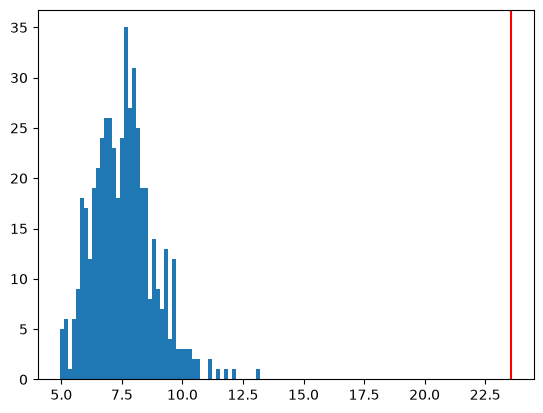

In [68]:
fig, ax = plt.subplots()
ax.hist(null[:, 2], bins=50)
ax.axvline(observed[2], color='red')
plt.show()

In [14]:
masks = m.significance_analysis(
    X_psth, trialX,
    n_shuffles=200, n_splits=5, n_consecutive=1, axis=True,
)

Compute score of data:  . . . . . Finished.
Compute score of shuffled data:  199 / 200 . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . .

In [15]:
masks

{'lt': array([[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]], shape=(10, 300)),
 'at': array([[False, False, False, ..., False, False,  True],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False,  True],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]], shape=(10, 300)),
 'lat': array([[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, 

In [16]:
Z = m.fit_transform(X_psth, trialX)

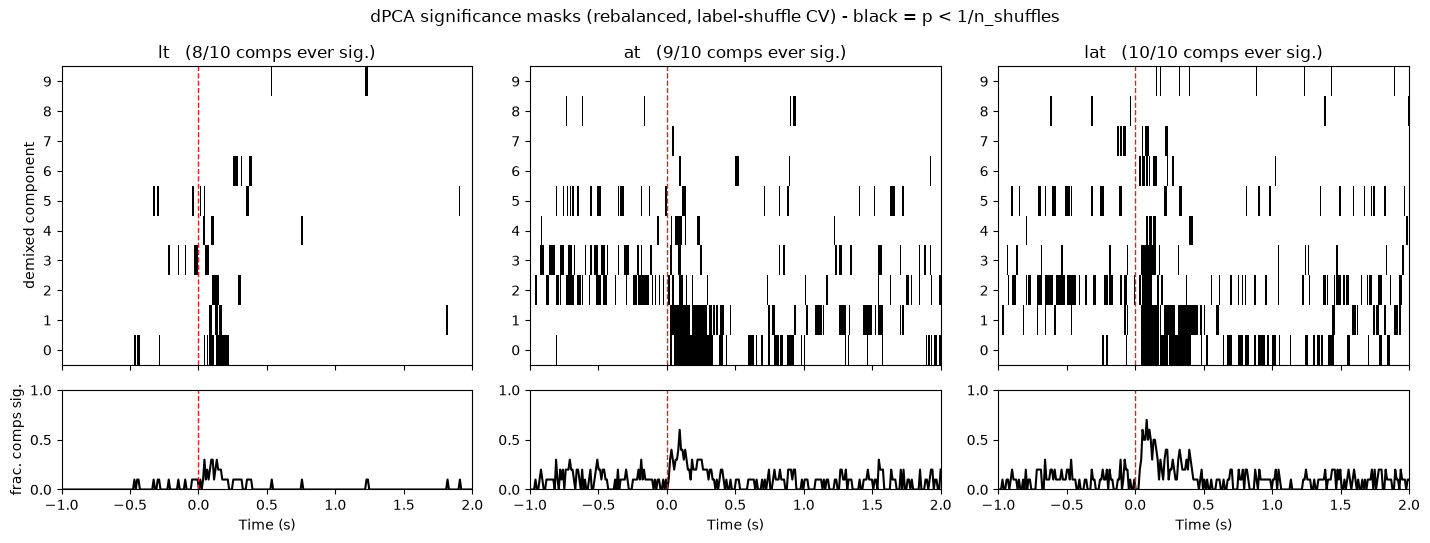

In [22]:
# Significance masks (rebalanced, label-shuffle CV). One (n_components x n_time)
# boolean grid per marginalization -- True where that demixed component's
# held-out nearest-centroid classification beats every one of the label
# shuffles (p < 1/n_shuffles). The pure-time marginalization is not tested;
# n_consecutive=1 above, so lone bins are not filtered out.
keys = list(masks)
n_comp, n_t = masks[keys[0]].shape
time = np.linspace(RESPONSE[0], RESPONSE[1], n_t)

fig, axs = plt.subplots(
    2, len(keys), figsize=(4.8 * len(keys), 5.5),
    sharex="col", gridspec_kw={"height_ratios": [3, 1]}, squeeze=False,
)

for j, key in enumerate(keys):
    mask = masks[key]                                   # (n_components, n_time)

    axs[0, j].imshow(
        mask, aspect="auto", origin="lower", cmap="Greys", vmin=0, vmax=1,
        interpolation="nearest",
        extent=[time[0], time[-1], -0.5, mask.shape[0] - 0.5],
    )
    axs[0, j].axvline(0, color="tab:red", ls="dashed", lw=1)
    axs[0, j].set_title(f"{key}   ({mask.any(axis=1).sum()}/{mask.shape[0]} comps ever sig.)")
    axs[0, j].set_yticks(range(mask.shape[0]))

    axs[1, j].plot(time, mask.mean(axis=0), color="k")   # frac. of comps sig. per bin
    axs[1, j].axvline(0, color="tab:red", ls="dashed", lw=1)
    axs[1, j].set_ylim(0, 1)
    axs[1, j].set_xlabel("Time (s)")

axs[0, 0].set_ylabel("demixed component")
axs[1, 0].set_ylabel("frac. comps sig.")
fig.suptitle("dPCA significance masks (rebalanced, label-shuffle CV) - black = p < 1/n_shuffles")
fig.tight_layout()


## Project single trials

In [9]:
CACHE_DIR = Params.ACROSS_SESSION_RESULTS_DIR / "cache"  # one <session>.npz per session
session = 'M061_2025_03_06_14_00'

d = np.load(CACHE_DIR / f"{session}.npz", allow_pickle=True)
onset = int(d["ep_onset"])
base_sl = slice(onset + int(BASE[0] * FS), onset + int(BASE[1] * FS))
resp_sl = slice(onset + int(RESPONSE[0] * FS), onset + int(RESPONSE[1] * FS))

X_ = d["ep_X"].astype(float)  # (n_ep, n_time_full, 57) body-frame keypoints
bl_std = X_[:, base_sl, :].std(axis=1, keepdims=True)  # (n_ep, 1, 57)
Xz = X_ / bl_std  # per-trial baseline z-score

keep = drop_by_perturb_score(d["ep_perturb_score"])
X = Xz[keep].transpose(0, 2, 1)[:, :, resp_sl]  # -> (n_trials, 57, n_time_resp)
codes = d["ep_code"][keep].astype(int)

  drop_by_perturb_score (sem, thresh=-2.0): dropped by sem: 36  |  dropped by value: 0  |  kept: 208/244 (85.2%)


In [24]:
factors = ["level", "angle"]  # dPCA non-time factors, names from dim.CONDITION_FACTORS
labels = "lat"

conds = dim.conditions_from_codes(codes, factors)
trialX, Xpsth, cond_values, counts = dim.build_unbalanced_trial_tensor(X, conds)

m = dim.RebalancedDPCA(
    labels=labels,
    regularizer=0.00032,
    join=dim.default_join(labels),
    n_components=15,
)
m.noise_var, m.protect = dim.rebalanced_noise_variance(trialX), [labels[-1]]
# m.fit(Xpsth, trialX)
Z = m.fit_transform(Xpsth, trialX)


In [ ]:
Z['t'].shape


fig, ax = plt.subplots

(15, 2, 6, 300)

In [15]:
import warnings
import numpy as np

def demean_trialX(trialX, feature_mean=None):
    
    n_features = trialX.shape[1]

    if feature_mean is None:
        with warnings.catch_warnings():
            warnings.filterwarnings("ignore", "Mean of empty slice", RuntimeWarning)
            X_uncentered = np.nanmean(trialX, axis=0)                  # (n_features, *cond_dims, n_time)
            by_feature = X_uncentered.reshape(n_features, -1)
            dead = np.all(np.isnan(by_feature), axis=1)
            feature_mean = np.zeros(n_features)
            feature_mean[~dead] = np.nanmean(by_feature[~dead], axis=1)

    # broadcast shape: (1, n_features, 1, 1, ..., 1) -- feature axis is axis 1 here,
    # not axis 0 (that's the trial axis), unlike X_psth where features are axis 0
    shape = (1, n_features) + (1,) * (trialX.ndim - 2)
    trialX_centered = trialX - feature_mean.reshape(shape)

    return trialX_centered, feature_mean

trialX_c, _ = demean_trialX(trialX)

In [18]:
trialX_c.shape

(25, 57, 2, 6, 300)

In [21]:
m.D['t'].shape

(57, 15)

In [22]:
Z = np.tensordot(m.D['t'], trialX_c, axes=([0], [1]))
Z.shape

(15, 25, 2, 6, 300)